In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier

result = {}

min_recall_st = {
    'ST1': 0.90, 'ST2': 0.85, 'ST3': 0.90, 'ST4': 0.85,
    'ST5': 0.85, 'ST6': 0.85, 'ST7': 0.80, 'ST8': 0.90,
}

#https://www.kaggle.com/code/dubltap/factory-oee-downtime-a-beginner-s-guide-with-s/notebook

#https://www.kaggle.com/code/vanchaud/iot-based-ml-monitoring/notebook

#https://www.kaggle.com/datasets/rauffauzanrambe/industrial-smart-factory-automation-dataset-2026

In [2]:
#downtime_evetns.csv — Downtime minutes .
df_downtime_events= pd.read_csv('source/output/downtime_events.csv')

#factory_synth_minutely.csv — Minutely time series for the line (per machine).
df_factory_minutely= pd.read_csv('source/output/factory_synth_minutely.csv')

#oee_by_day.csv — OEE aggregates by machine × day.
df_oee_day= pd.read_csv('source/output/oee_by_day.csv')

#oee_by_shift.csv — OEE aggregates by machine × day × shift (A/B/C).
df_oee_shift= pd.read_csv('source/output/oee_by_shift.csv')

C:\Users\alber\AppData\Local\Temp\ipykernel_19036\174150755.py:5: DtypeWarning: Columns (0: stop_reason_detail) have mixed types. Specify dtype option on import or set low_memory=False.
  df_factory_minutely= pd.read_csv('source/output/factory_synth_minutely.csv')


## Functions

In [3]:
def Prepare_Station_Data(dataset):
    sensors_col = ['vibration', 'air_pressure', 'temperature', 'energy_consumption', 'humidity']

    # Delete Sensors Columns with all data null
    for s in sensors_col:
        if s in dataset.columns and dataset[s].isnull().all():
            dataset = dataset.drop(columns=s)

    # Create new column for remaining sensors and write True if a failure is registred.
    for s in sensors_col:
        if s in dataset.columns:
            dataset[f'{s}_fail'] = dataset['trigger_sensor'] == s

    # Create 'Operator not feed' Column if exist in stop_reason_detail (Robotics ST Only)
    if 'stop_reason_detail' in dataset.columns:
        dataset['Operator not feed'] = dataset['stop_reason_detail'] == 'Operator supply gap (infeed not replenished)'
        dataset = dataset.drop(columns=['stop_reason_detail'])
    else:
        dataset['Operator not feed'] = False

    dataset['timestamp'] = pd.to_datetime(dataset['timestamp'])

    sensor_present = []
    for col in dataset.columns:
        if col in sensors_col:
            sensor_present.append(col)
    print(f"Sensors in {dataset['station_id'].unique()[0]}: {sensor_present}.")

    dataset = dataset.drop(columns=['day', 'process', 'sequence_order', 'station_type', 'machine'])

    return dataset


def Calculate_Mean_Max_Min(dataset, Cause_col, col_measure):
    mean=dataset[dataset[Cause_col] == True][col_measure].mean()
    max=dataset[dataset[Cause_col] == True][col_measure].max()
    min=dataset[dataset[Cause_col] == True][col_measure].min()

    print(f"Mean {col_measure}: {mean}")
    print(f"Min {col_measure}: {min}")
    print(f"Max {col_measure}: {max}")

    result = {'mean': mean, 'min': min, 'max': max,}

    return result

def plot_trigger_sensors(dataset, sensors_STx, station_name='Station'):
    dataset = dataset.sort_values('timestamp').reset_index(drop=True)


    for sensor, mean in sensors_STx.items():
        trig_idx_all = dataset.index[dataset['trigger_sensor'] == sensor]
        if len(trig_idx_all) == 0:
            continue

        idx = trig_idx_all[0]
        window = dataset.iloc[max(0, idx - 150):idx+15]

        fig, ax = plt.subplots(figsize=(11, 5))
        ax.plot(window['timestamp'], window[sensor], color='steelblue', linewidth=1.5, label=sensor)
        ax.axhline(mean, color='red', linestyle='--', linewidth=1, label=f'Mean {sensor} Failure ({mean})')
        ax.axvline(dataset.loc[idx, 'timestamp'], color='red', linestyle=':', linewidth=1.2, label=f'{sensor} Triggered')
        ax.set_title(f'{station_name} — {sensor} Failure Timestamp')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel(sensor)
        ax.legend()
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

def analyze_station_sensors(df_STx, station_name):
    sensor_values = ['vibration', 'air_pressure', 'temperature', 'energy_consumption', 'humidity']

    df_mech = df_STx[df_STx['cause_Mechanical']==1]
    df_elec = df_STx[df_STx['cause_Electrical']==1]

    sensors_STx = {}

    # Calculate Mean Max Min for the present sensors which generates Mechanical Cause 
    for s in sensor_values:
        fail_col = f'{s}_fail'
        if fail_col in df_STx.columns and df_mech[fail_col].any():
            r = Calculate_Mean_Max_Min(df_mech, fail_col, s)
            sensors_STx[s] = r['mean']
            print("----------------------------------------")

    # Calculate Mean Max Min for the present sensors which generates Electrical Cause 
    for s in sensor_values:
        fail_col = f'{s}_fail'
        if fail_col in df_STx.columns and df_elec[fail_col].any():
            r = Calculate_Mean_Max_Min(df_elec, fail_col, s)
            sensors_STx[s] = r['mean']
            print("----------------------------------------")

    plot_trigger_sensors(df_STx, sensors_STx, station_name=station_name)

    return sensors_STx



def build_features_and_target(dataset, sensors_STx, target_window=30, rolling_window=15):
    event = ((dataset['cause_Mechanical']==1) | (dataset['cause_Electrical']==1)).astype(int)
    dataset['target'] = event[::-1].rolling(target_window, min_periods=1).max()[::-1].shift(-1).fillna(0).astype(int)

    for s in sensors_STx:
        dataset[f'{s}_mean15'] = dataset[s].rolling(rolling_window, min_periods=1).mean()
        dataset[f'{s}_std15']  = dataset[s].rolling(rolling_window, min_periods=1).std().fillna(0)
        dataset[f'{s}_slope15'] = dataset[s] - dataset[s].shift(rolling_window)
        dataset[f'{s}_curr'] = dataset[s]

    feature_cols = []
    for s in sensors_STx:
        feature_cols += [f'{s}_mean15', f'{s}_std15', f'{s}_slope15', f'{s}_curr']

    dataset = dataset.dropna(subset=feature_cols).reset_index(drop=True)

    print(f"Target = 1: {dataset['target'].sum()} / {len(dataset)} ({dataset['target'].mean()*100:.1f}%)")

    return dataset, feature_cols


def evaluate_with_threshold(model, X, y, threshold):
    """
    Evaluates a model using a CUSTOM decision threshold instead of the
    default 0.5 — this is what makes the reported metrics reflect the
    calibrated threshold, not the default one.
    """
    probs = model.predict_proba(X)[:, 1]
    y_pred = (probs >= threshold).astype(int)
    return {
        'acc': accuracy_score(y, y_pred),
        'prec': precision_score(y, y_pred),
        'rec': recall_score(y, y_pred),
        'f1': f1_score(y, y_pred),
    }


def optimal_threshold(model, X_test, y_test, min_recall):
    """
    Among all thresholds that keep Recall >= min_recall,
    pick the one with the highest Precision.
    """
    probs = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
    precisions, recalls = precisions[:-1], recalls[:-1]

    valid = recalls >= min_recall
    if not valid.any():
        return 0.5

    valid_thresholds = thresholds[valid]
    valid_precisions = precisions[valid]

    best_i = np.argmax(valid_precisions)
    return float(valid_thresholds[best_i])


def train_evaluate_station_models(df_STx, feature_cols, station_name):
    min_recall = min_recall_st[station_name]

    split_date = df_STx['timestamp'].quantile(0.8)
    train = df_STx[df_STx['timestamp'] < split_date]
    test  = df_STx[df_STx['timestamp'] >= split_date].reset_index(drop=True)

    X_train, y_train = train[feature_cols], train['target']
    X_test, y_test = test[feature_cols], test['target']

    # --- Random Forest ---
    model_rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
    model_rf.fit(X_train, y_train)
    importances_rf = pd.Series(model_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

    threshold_rf = optimal_threshold(model_rf, X_test, y_test, min_recall=min_recall)
    test_metrics_rf = evaluate_with_threshold(model_rf, X_test, y_test, threshold_rf)
    train_metrics_rf = evaluate_with_threshold(model_rf, X_train, y_train, threshold_rf)
    rf_evalutation = {
        **test_metrics_rf,
        'train_acc': train_metrics_rf['acc'],
        'test_acc': test_metrics_rf['acc'],
        'gap': train_metrics_rf['acc'] - test_metrics_rf['acc'],
    }

    print(f"------ Evaluation: Random Forest --------")
    print(f"Threshold: {threshold_rf:.3f}")
    print(f"Accuracy: {rf_evalutation['acc']:.4f}")
    print(f"Precision: {rf_evalutation['prec']:.4f}")
    print(f"Recall: {rf_evalutation['rec']:.4f}")
    print(f"F1 Score: {rf_evalutation['f1']:.4f}")
    print(f"------------------------------")
    print(f"Accuracy in TRAIN: {rf_evalutation['train_acc']:.4f}")
    print(f"Accuracy in TEST:  {rf_evalutation['test_acc']:.4f}")
    print(f"Gap: {rf_evalutation['gap']:.4f}")
    print(f"------------------------------")

    # --- XGBoost ---
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    model_xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
                               colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
                               eval_metric="logloss", random_state=42, n_jobs=-1)
    model_xgb.fit(X_train, y_train)
    importances_xgb = pd.Series(model_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)

    threshold_xgb = optimal_threshold(model_xgb, X_test, y_test, min_recall=min_recall)
    test_metrics_xgb = evaluate_with_threshold(model_xgb, X_test, y_test, threshold_xgb)
    train_metrics_xgb = evaluate_with_threshold(model_xgb, X_train, y_train, threshold_xgb)
    xgb_evaluation = {
        **test_metrics_xgb,
        'train_acc': train_metrics_xgb['acc'],
        'test_acc': test_metrics_xgb['acc'],
        'gap': train_metrics_xgb['acc'] - test_metrics_xgb['acc'],
    }

    print(f"------ Evaluation: XGBoost --------")
    print(f"Threshold: {threshold_xgb:.3f}")
    print(f"Accuracy: {xgb_evaluation['acc']:.4f}")
    print(f"Precision: {xgb_evaluation['prec']:.4f}")
    print(f"Recall: {xgb_evaluation['rec']:.4f}")
    print(f"F1 Score: {xgb_evaluation['f1']:.4f}")
    print(f"------------------------------")
    print(f"Accuracy in TRAIN: {xgb_evaluation['train_acc']:.4f}")
    print(f"Accuracy in TEST:  {xgb_evaluation['test_acc']:.4f}")
    print(f"Gap: {xgb_evaluation['gap']:.4f}")
    print(f"------------------------------")

    comparison = pd.DataFrame({
        "Model": ["Random Forest", "XGBoost"],
        "Accuracy": [rf_evalutation['acc'], xgb_evaluation['acc']],
        "Precision": [rf_evalutation['prec'], xgb_evaluation['prec']],
        "Recall": [rf_evalutation['rec'], xgb_evaluation['rec']],
        "F1 Score": [rf_evalutation['f1'], xgb_evaluation['f1']],
        "Train-Test Gap": [rf_evalutation['gap'], xgb_evaluation['gap']],
        "Threshold": [threshold_rf, threshold_xgb],
    })

    return {
        'df': df_STx, 'test_df': test, 'feature_cols': feature_cols,
        'rf': model_rf, 'xgb': model_xgb,
        'rf_eval': rf_evalutation, 'xgb_eval': xgb_evaluation,
        'threshold_rf': threshold_rf, 'threshold_xgb': threshold_xgb,
        'importances_rf': importances_rf, 'importances_xgb': importances_xgb,
        'comparison': comparison,
    }

def plot_feature_importances(importances_rf, importances_xgb, station_name='Station', top_n=10):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    importances_rf.head(top_n).plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title(f'{station_name} — Random Forest')
    axes[0].invert_yaxis()

    importances_xgb.head(top_n).plot(kind='barh', ax=axes[1], color='darkorange')
    axes[1].set_title(f'{station_name} — XGBoost')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

def downtime_duration_by_cause(downtime_events, station_id):
    df_st = downtime_events[downtime_events['station_id'] == station_id]
    summary = df_st.groupby('cause')['minutes'].agg(['mean', 'median', 'min', 'max', 'count']).round(1)
    summary = summary.sort_values('mean', ascending=False)
    return summary

# EDA

In [4]:
df_factory_minutely.head()

,timestamp,machine,is_running,cause_Mechanical,cause_Electrical,cause_Changeover,cause_Blocked,cause_Starved,cause_Quality,trigger_sensor,...,scrap,good_units,station_id,station_type,process,sequence_order,humidity,shift,day,stop_reason_detail
0,2025-01-01 06:00:00,M1,1,0,0,0,0,0,0,NaN,...,0,6,ST1,Robotics,Product Introduction [1],1,NaN,A,2025-01-01,NaN
1,2025-01-01 06:01:00,M1,1,0,0,0,0,0,0,NaN,...,0,6,ST1,Robotics,Product Introduction [1],1,NaN,A,2025-01-01,NaN
2,2025-01-01 06:02:00,M1,1,0,0,0,0,0,0,NaN,...,0,7,ST1,Robotics,Product Introduction [1],1,NaN,A,2025-01-01,NaN
3,2025-01-01 06:03:00,M1,1,0,0,0,0,0,0,NaN,...,0,6,ST1,Robotics,Product Introduction [1],1,NaN,A,2025-01-01,NaN
4,2025-01-01 06:04:00,M1,1,0,0,0,0,0,0,NaN,...,0,7,ST1,Robotics,Product Introduction [1],1,NaN,A,2025-01-01,NaN


In [5]:
df_factory_minutely.info()
print(f"""
----------------------------------------------------------
Duplicated rows: {df_factory_minutely.duplicated().sum()}
----------------------------------------------------------
""")

<class 'pandas.DataFrame'>
RangeIndex: 345600 entries, 0 to 345599
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   timestamp           345600 non-null  str    
 1   machine             345600 non-null  str    
 2   is_running          345600 non-null  int64  
 3   cause_Mechanical    345600 non-null  int64  
 4   cause_Electrical    345600 non-null  int64  
 5   cause_Changeover    345600 non-null  int64  
 6   cause_Blocked       345600 non-null  int64  
 7   cause_Starved       345600 non-null  int64  
 8   cause_Quality       345600 non-null  int64  
 9   trigger_sensor      1608 non-null    str    
 10  vibration           259200 non-null  float64
 11  air_pressure        302400 non-null  float64
 12  temperature         216000 non-null  float64
 13  energy_consumption  345600 non-null  float64
 14  units               345600 non-null  int64  
 15  scrap               345600 non-null  int64  


In [6]:
df_factory_minutely['cause_Electrical'].sum()

np.int64(844)

In [7]:
df_factory_minutely['cause_Mechanical'].sum()

np.int64(773)

In [8]:
df_factory_minutely['machine'].unique()

<ArrowStringArray>
['M1']
Length: 1, dtype: str

In [9]:
df_factory_minutely['station_id'].unique()

<ArrowStringArray>
['ST1', 'ST2', 'ST3', 'ST4', 'ST5', 'ST6', 'ST7', 'ST8']
Length: 8, dtype: str

In [10]:
df_factory_minutely['trigger_sensor'].unique()

<ArrowStringArray>
[                 nan,          'vibration',       'air_pressure',
        'temperature', 'energy_consumption',           'humidity',
         'scrap_rule']
Length: 7, dtype: str

## Split Assembly Line in Stations

1. #### ST1 (Robotics)

In [11]:
print(f"Station Type: {df_factory_minutely[df_factory_minutely['station_id'] == 'ST1']['station_type'].unique()[0]}")

Station Type: Robotics


In [12]:
df_ST1 = Prepare_Station_Data(df_factory_minutely[df_factory_minutely['station_id'] == 'ST1'])

Sensors in ST1: ['vibration', 'air_pressure', 'temperature', 'energy_consumption'].


In [13]:
df_ST1['cause_Mechanical'].value_counts()

cause_Mechanical
0    43084
1      116
Name: count, dtype: int64

In [14]:
df_ST1['cause_Electrical'].value_counts()

cause_Electrical
0    43084
1      116
Name: count, dtype: int64

In [15]:
df_ST1['cause_Changeover'].value_counts()

cause_Changeover
0    43184
1       16
Name: count, dtype: int64

In [16]:
df_ST1['cause_Blocked'].value_counts()

cause_Blocked
0    42297
1      903
Name: count, dtype: int64

In [17]:
df_ST1['cause_Starved'].value_counts()

cause_Starved
0    43084
1      116
Name: count, dtype: int64

In [18]:
df_ST1['cause_Quality'].value_counts()

cause_Quality
0    43183
1       17
Name: count, dtype: int64

Mean vibration: 58.69663775916438
Min vibration: 57.65882633693269
Max vibration: 59.96704129670994
----------------------------------------
Mean air_pressure: 3.158741272816126
Min air_pressure: 3.018066767624765
Max air_pressure: 3.344982794202838
----------------------------------------
Mean temperature: 89.64186044420674
Min temperature: 87.98421947542165
Max temperature: 91.7709447530336
----------------------------------------
Mean energy_consumption: 4.526664573928732
Min energy_consumption: 4.372843930344848
Max energy_consumption: 4.720260138678513
----------------------------------------


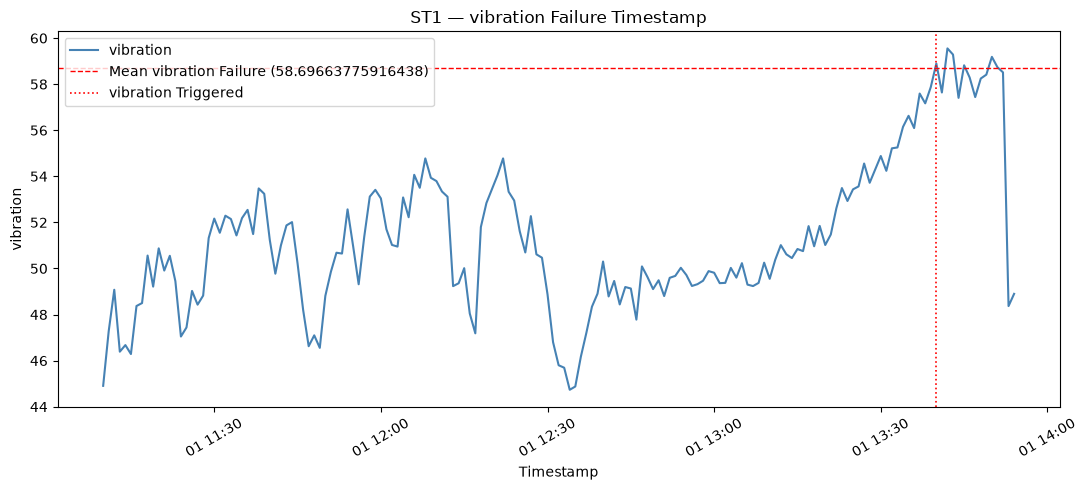

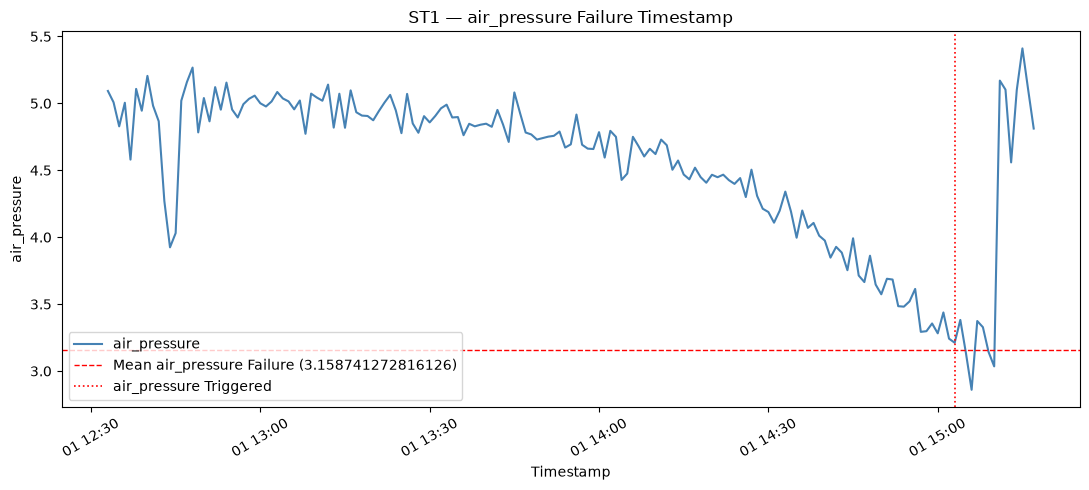

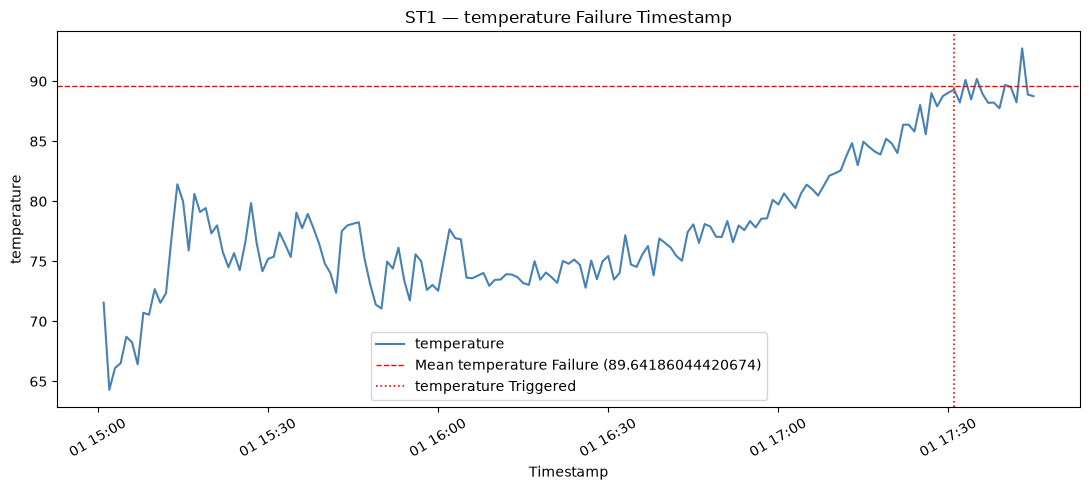

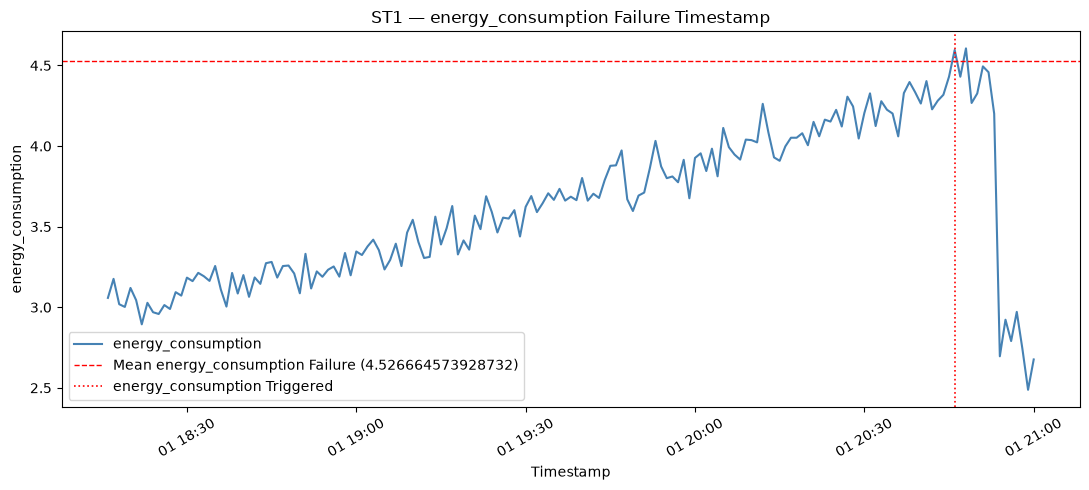

In [19]:
split_date = df_ST1['timestamp'].quantile(0.8)
split_train = df_ST1[df_ST1['timestamp'] < split_date]

sensors_ST1 = analyze_station_sensors(split_train, 'ST1')

In [20]:
df_ST1, feature_cols_ST1 = build_features_and_target(df_ST1, list(sensors_ST1.keys()))

Target = 1: 6851 / 43185 (15.9%)


In [21]:
feature_cols_ST1

['vibration_mean15',
 'vibration_std15',
 'vibration_slope15',
 'vibration_curr',
 'air_pressure_mean15',
 'air_pressure_std15',
 'air_pressure_slope15',
 'air_pressure_curr',
 'temperature_mean15',
 'temperature_std15',
 'temperature_slope15',
 'temperature_curr',
 'energy_consumption_mean15',
 'energy_consumption_std15',
 'energy_consumption_slope15',
 'energy_consumption_curr']

- Creating all this columns Model could predict better the pattern to detect next failure not just using the current value.
- Model can see the mean, if its oscillating, if its going up or down and the current value.

## Random Forest Vs Gradient Boosting (XGBoost)

Random Forest and Gradient Boosting are the models selected to predict future fails in the Line.

After Random Forest and Gradient Boosting will be compared to find the best model.

##### Random Forest:
- Model will be trainned with the hyperparameter class_weight='balanced' because 16% of the target are positive.
##### XGBoost:
- Model will be trainned with the hyperparameter scale_pos_weight [Class_weiht in Random Forest] ='balanced' because 16% of the target are positive.

In [22]:
result['ST1'] = {**train_evaluate_station_models(df_ST1, feature_cols_ST1, 'ST1'), 'sensors': sensors_ST1}

------ Evaluation: Random Forest --------
Threshold: 0.431
Accuracy: 0.9037
Precision: 0.6512
Recall: 0.9007
F1 Score: 0.7559
------------------------------
Accuracy in TRAIN: 0.9293
Accuracy in TEST:  0.9037
Gap: 0.0256
------------------------------
------ Evaluation: XGBoost --------
Threshold: 0.553
Accuracy: 0.9239
Precision: 0.7146
Recall: 0.9000
F1 Score: 0.7967
------------------------------
Accuracy in TRAIN: 0.9454
Accuracy in TEST:  0.9239
Gap: 0.0214
------------------------------


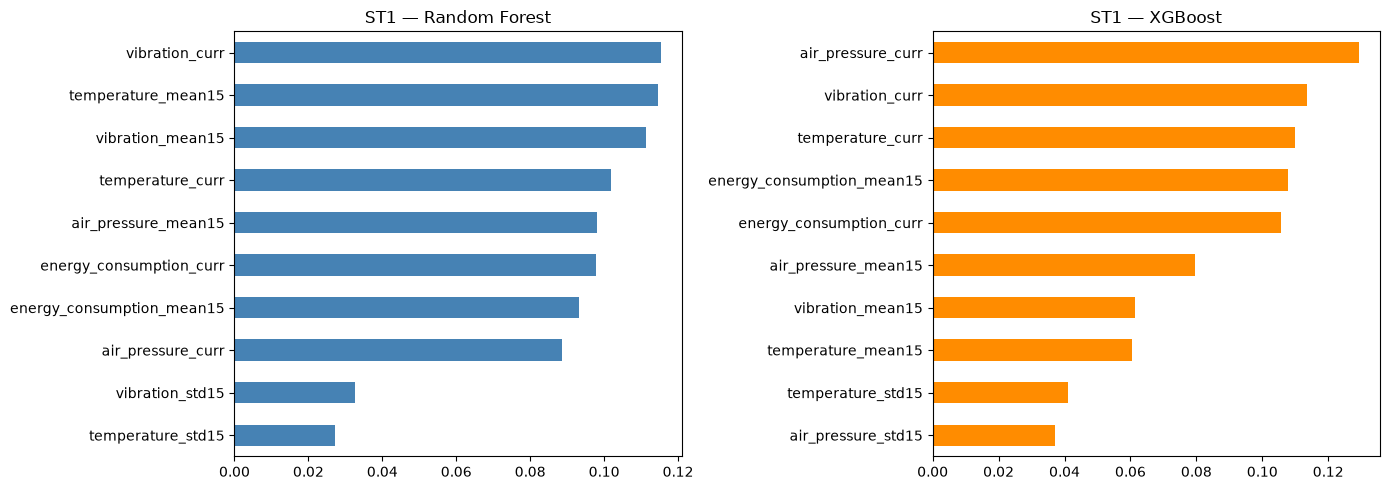

In [23]:
plot_feature_importances(result['ST1']['importances_rf'], result['ST1']['importances_xgb'], station_name='ST1')

Remember: In Target, 16% are positive. That's why There is a huge gap between Accuracy and Prec/Recall.


## Random Forest vs XGBoost

Comparison between models.

In [24]:
result['ST1']['comparison']  

,Model,Accuracy,Precision,Recall,F1 Score,Train-Test Gap,Threshold
0,Random Forest,0.903670,0.651163,0.900699,0.755869,0.025617,0.431301
1,XGBoost,0.923932,0.714603,0.900000,0.796657,0.021448,0.553186


2. #### ST2 (CNC)

In [25]:
print(f"Station Type: {df_factory_minutely[df_factory_minutely['station_id'] == 'ST2']['station_type'].unique()[0]}")

Station Type: CNC


In [26]:
df_ST2 = Prepare_Station_Data(df_factory_minutely[df_factory_minutely['station_id'] == 'ST2'])

Sensors in ST2: ['vibration', 'air_pressure', 'temperature', 'energy_consumption', 'humidity'].


Mean vibration: 58.670959424811414
Min vibration: 57.34965762503306
Max vibration: 59.45242224458638
----------------------------------------
Mean air_pressure: 3.1753953284052425
Min air_pressure: 3.052534905385852
Max air_pressure: 3.382418931515243
----------------------------------------
Mean temperature: 89.64997268911819
Min temperature: 88.29054392200385
Max temperature: 90.5203614421912
----------------------------------------
Mean energy_consumption: 4.530642961700401
Min energy_consumption: 4.297021248099257
Max energy_consumption: 4.6615443655518
----------------------------------------
Mean humidity: 75.44261526115731
Min humidity: 73.35482904803875
Max humidity: 77.76644246088213
----------------------------------------


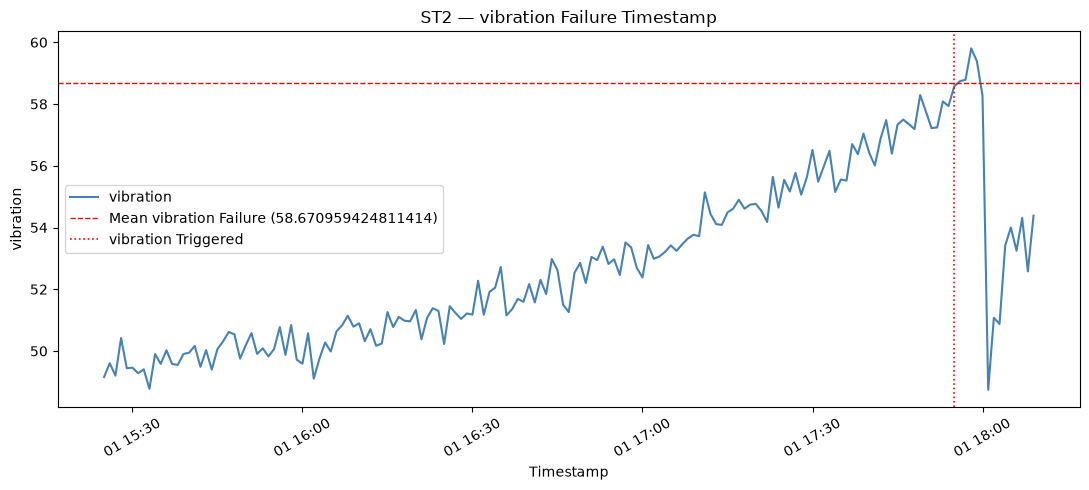

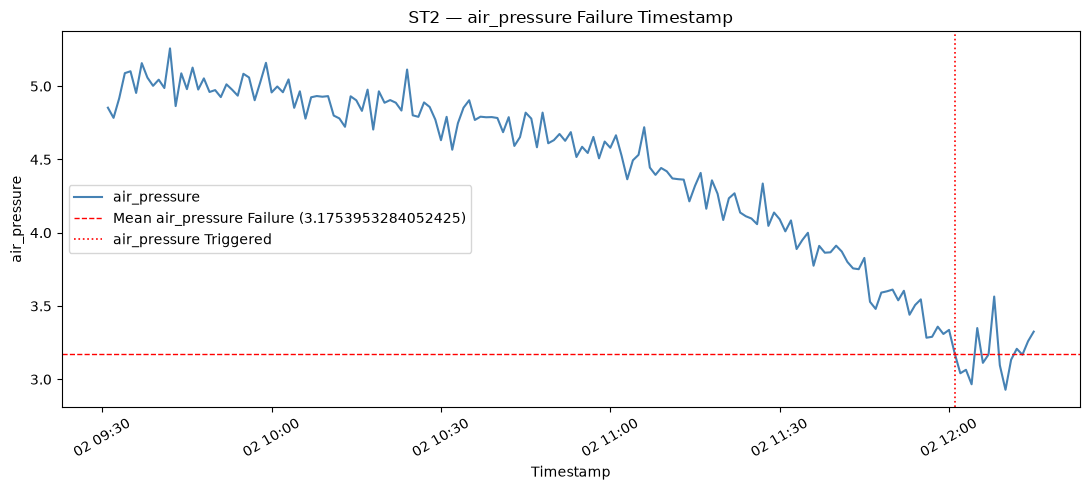

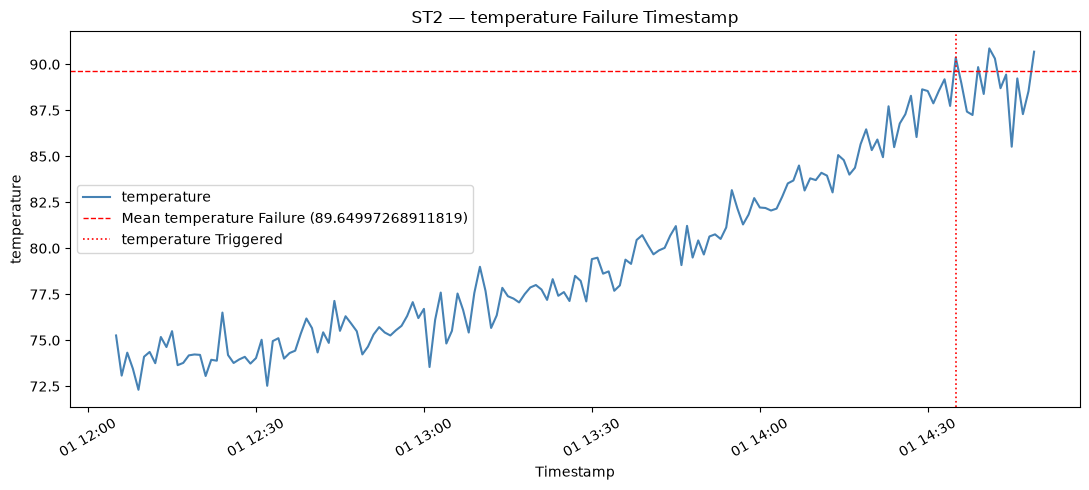

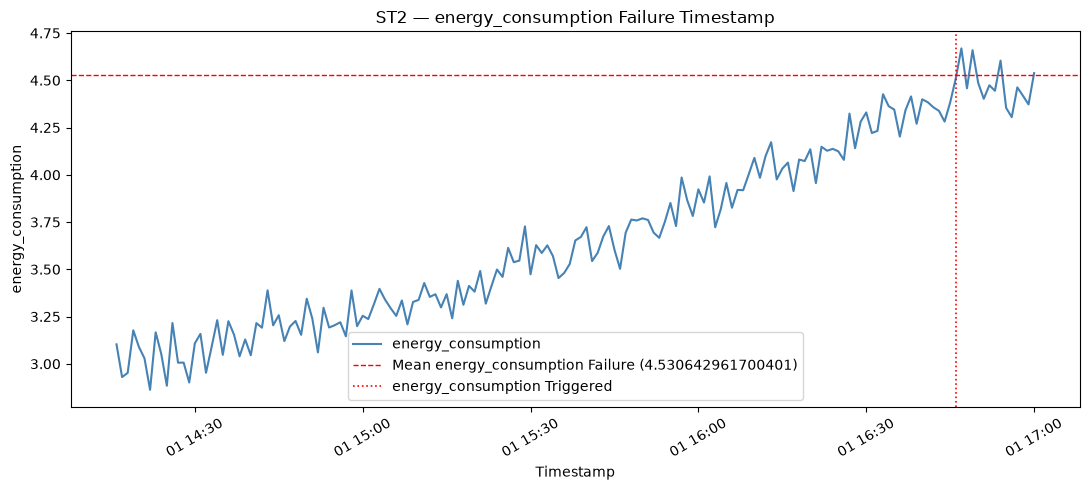

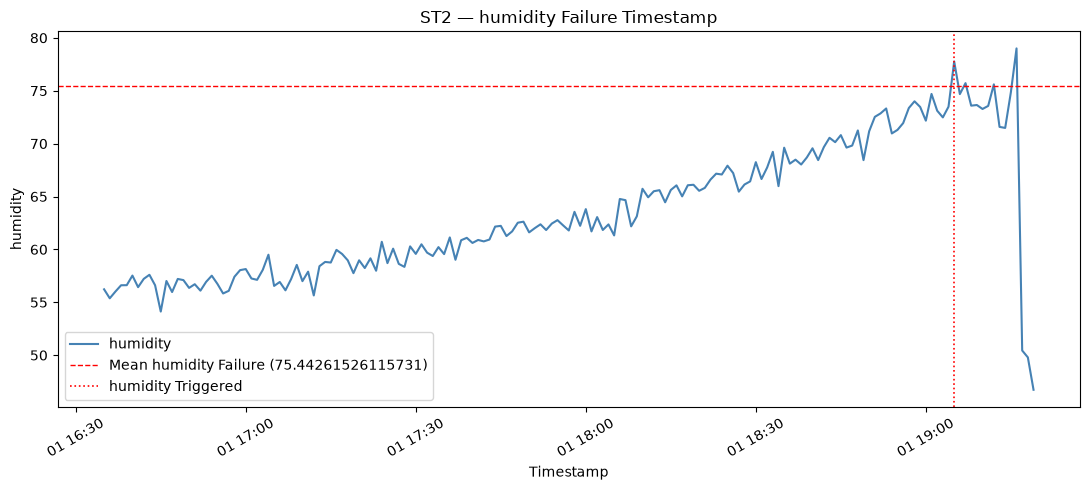

In [27]:
split_date = df_ST2['timestamp'].quantile(0.8)
split_train = df_ST2[df_ST2['timestamp'] < split_date]

sensors_ST2 = analyze_station_sensors(split_train, 'ST2')

In [28]:
df_ST2, feature_cols_ST2 = build_features_and_target(df_ST2, list(sensors_ST2.keys()))

Target = 1: 7681 / 43185 (17.8%)


In [29]:
result['ST2'] = {**train_evaluate_station_models(df_ST2, feature_cols_ST2, 'ST2'), 'sensors': sensors_ST2}

------ Evaluation: Random Forest --------
Threshold: 0.542
Accuracy: 0.9016
Precision: 0.6726
Recall: 0.8501
F1 Score: 0.7510
------------------------------
Accuracy in TRAIN: 0.9353
Accuracy in TEST:  0.9016
Gap: 0.0337
------------------------------
------ Evaluation: XGBoost --------
Threshold: 0.580
Accuracy: 0.9136
Precision: 0.7112
Recall: 0.8508
F1 Score: 0.7748
------------------------------
Accuracy in TRAIN: 0.9428
Accuracy in TEST:  0.9136
Gap: 0.0292
------------------------------


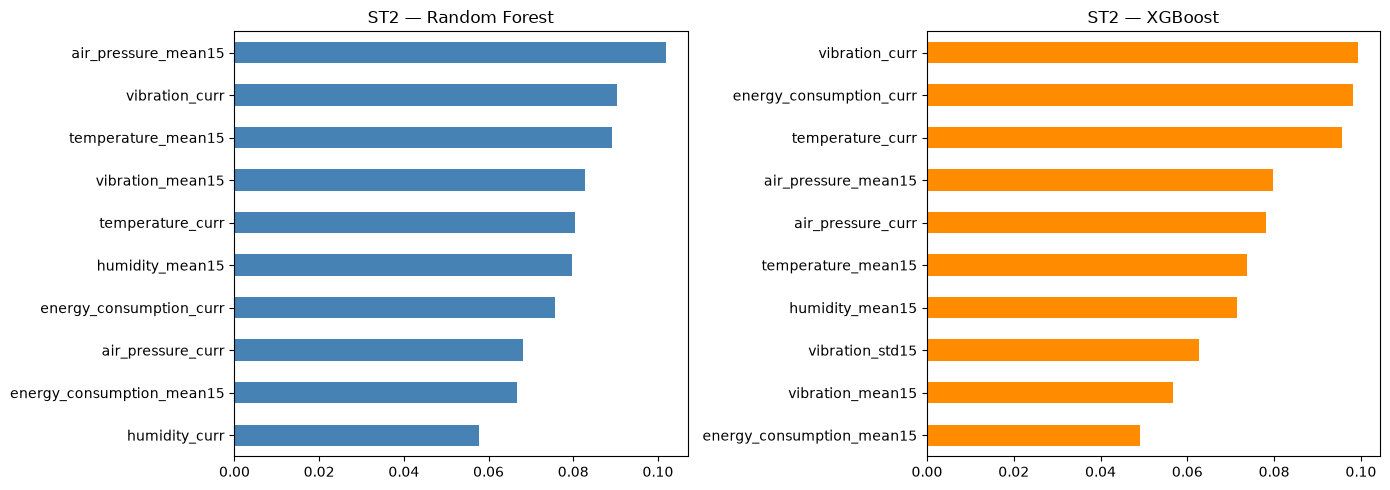

In [30]:
plot_feature_importances(result['ST2']['importances_rf'], result['ST2']['importances_xgb'], station_name='ST2')

In [31]:
result['ST2']['comparison']  

,Model,Accuracy,Precision,Recall,F1 Score,Train-Test Gap,Threshold
0,Random Forest,0.901586,0.672613,0.850133,0.751025,0.033721,0.542344
1,XGBoost,0.913627,0.711197,0.850796,0.774758,0.029177,0.580225


3. #### ST3 (Robotics)

In [32]:
print(f"Station Type: {df_factory_minutely[df_factory_minutely['station_id'] == 'ST3']['station_type'].unique()[0]}")

Station Type: Robotics


Sensors in ST3: ['vibration', 'air_pressure', 'temperature', 'energy_consumption'].
Mean vibration: 58.58902793112086
Min vibration: 57.31895688948397
Max vibration: 59.29180472953037
----------------------------------------
Mean air_pressure: 3.1641258358301987
Min air_pressure: 3.0380117420858928
Max air_pressure: 3.388875195040378
----------------------------------------
Mean temperature: 89.75257898848159
Min temperature: 88.23446928286512
Max temperature: 91.05340849489612
----------------------------------------
Mean energy_consumption: 4.525054112823269
Min energy_consumption: 4.3021356074358446
Max energy_consumption: 4.714699735698452
----------------------------------------


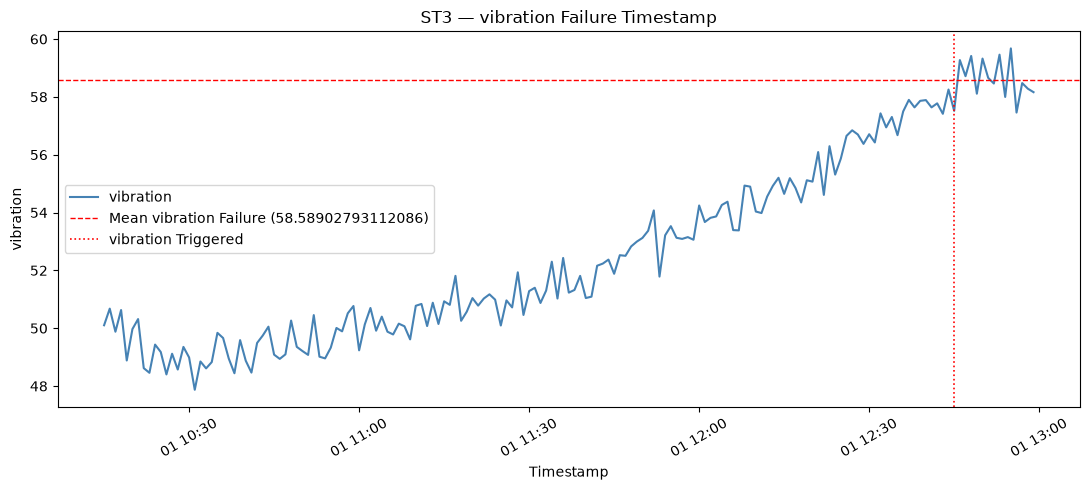

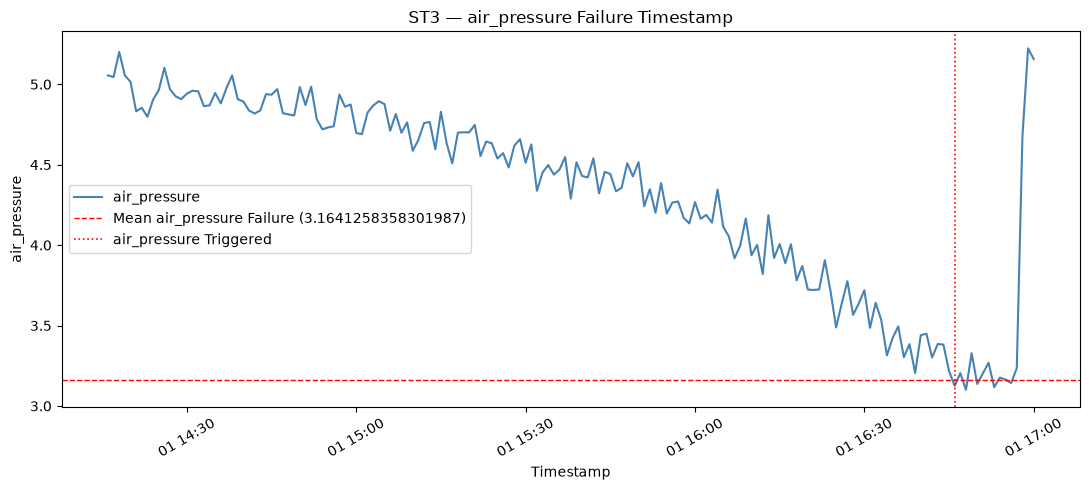

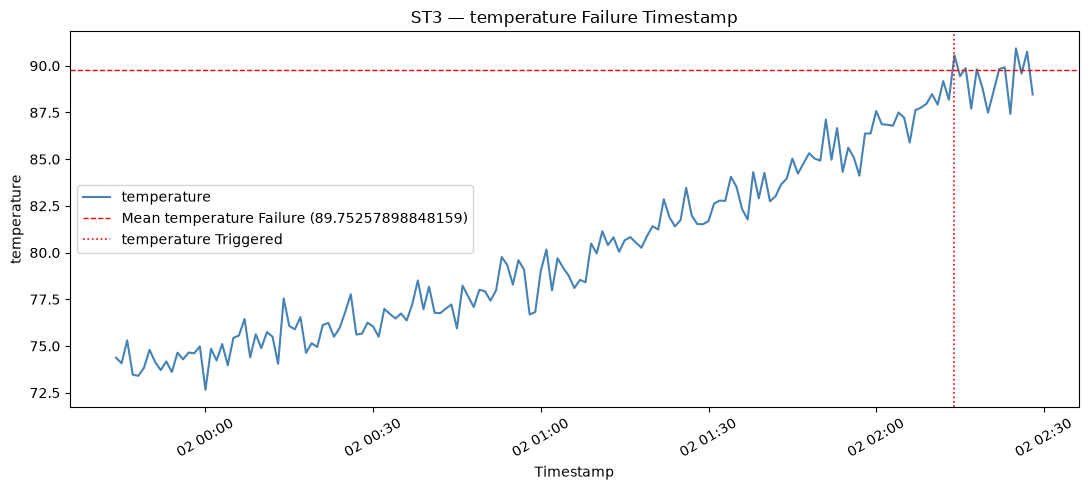

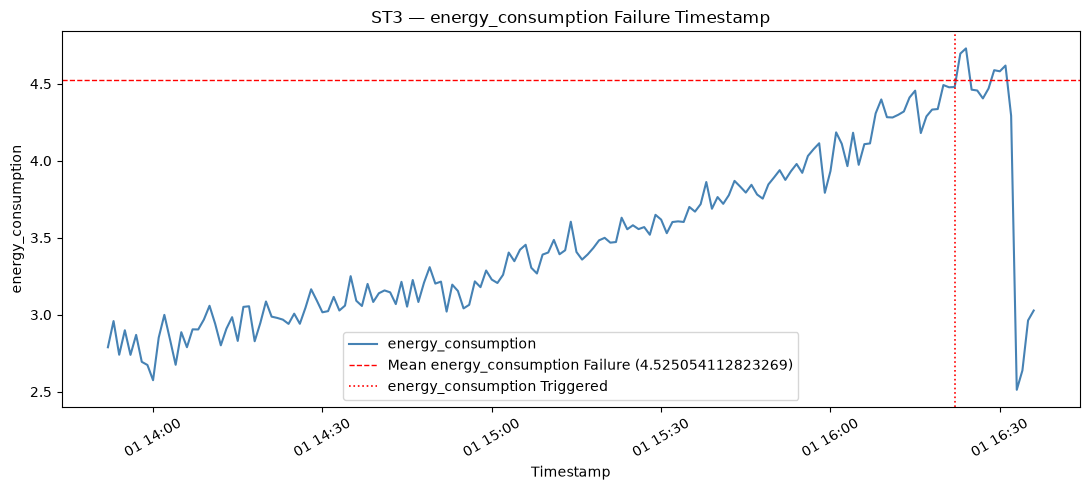

Target = 1: 6991 / 43185 (16.2%)
------ Evaluation: Random Forest --------
Threshold: 0.690
Accuracy: 0.9375
Precision: 0.7500
Recall: 0.9000
F1 Score: 0.8182
------------------------------
Accuracy in TRAIN: 0.9503
Accuracy in TEST:  0.9375
Gap: 0.0129
------------------------------
------ Evaluation: XGBoost --------
Threshold: 0.728
Accuracy: 0.9426
Precision: 0.7709
Recall: 0.9000
F1 Score: 0.8305
------------------------------
Accuracy in TRAIN: 0.9548
Accuracy in TEST:  0.9426
Gap: 0.0123
------------------------------


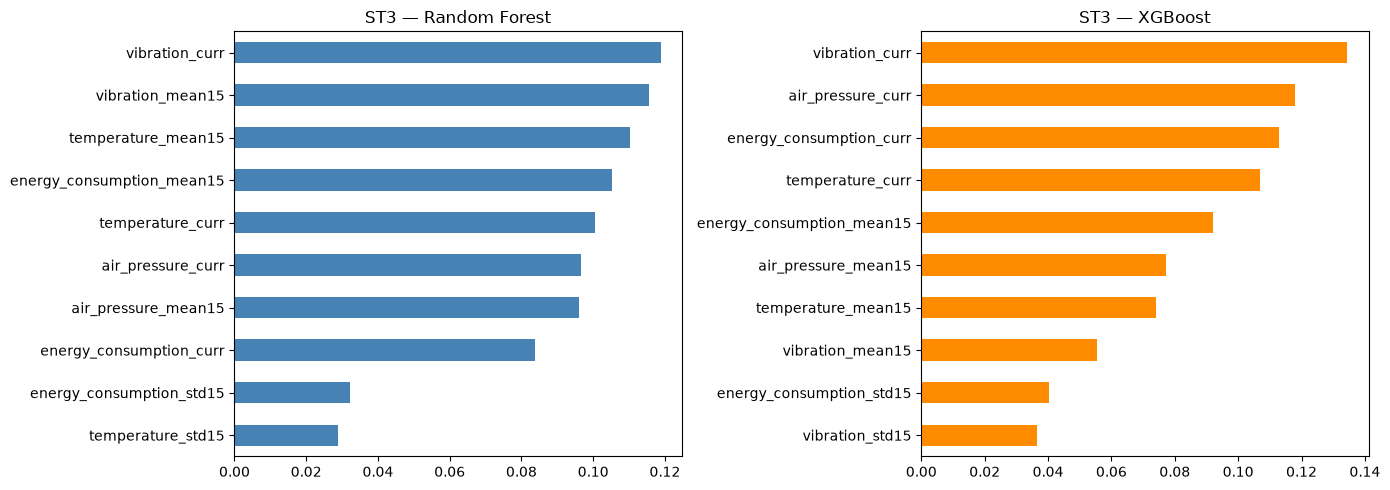

In [33]:
df_ST3 = Prepare_Station_Data(df_factory_minutely[df_factory_minutely['station_id'] == 'ST3'])

split_date = df_ST3['timestamp'].quantile(0.8)
split_train = df_ST3[df_ST3['timestamp'] < split_date]

sensors_ST3 = analyze_station_sensors(split_train, 'ST3')

df_ST3, feature_cols_ST3 = build_features_and_target(df_ST3, list(sensors_ST3.keys()))
result['ST3'] = {**train_evaluate_station_models(df_ST3, feature_cols_ST3, 'ST3'), 'sensors': sensors_ST3}

plot_feature_importances(result['ST3']['importances_rf'], result['ST3']['importances_xgb'], station_name='ST3')

In [34]:
result['ST3']['comparison']  

,Model,Accuracy,Precision,Recall,F1 Score,Train-Test Gap,Threshold
0,Random Forest,0.937478,0.750000,0.9,0.818182,0.012852,0.690312
1,XGBoost,0.942573,0.770939,0.9,0.830485,0.012273,0.727826


4. #### ST4 (Assembly)

In [35]:
print(f"Station Type: {df_factory_minutely[df_factory_minutely['station_id'] == 'ST4']['station_type'].unique()[0]}")

Station Type: Assembly


Sensors in ST4: ['vibration', 'air_pressure', 'energy_consumption'].
Mean vibration: 58.76904477451447
Min vibration: 57.915781591262
Max vibration: 59.7968435735827
----------------------------------------
Mean air_pressure: 3.1501587343186777
Min air_pressure: 3.0027930773769973
Max air_pressure: 3.282564622123328
----------------------------------------
Mean energy_consumption: 4.541003575654842
Min energy_consumption: 4.34543953967915
Max energy_consumption: 4.691540001900152
----------------------------------------


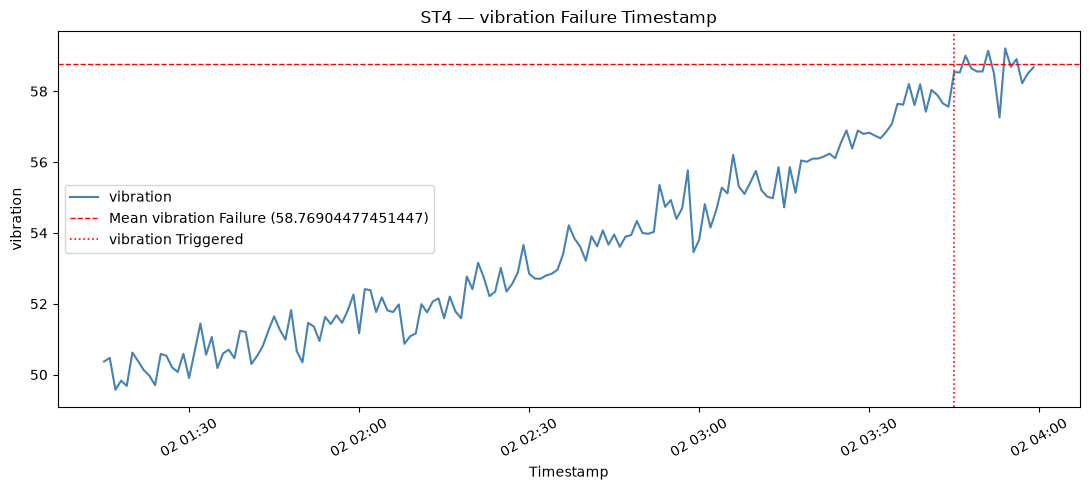

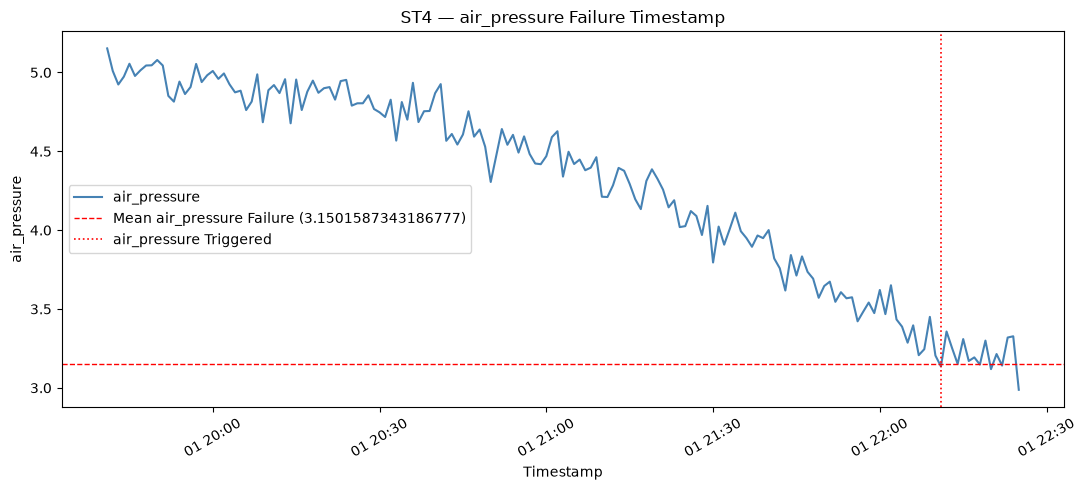

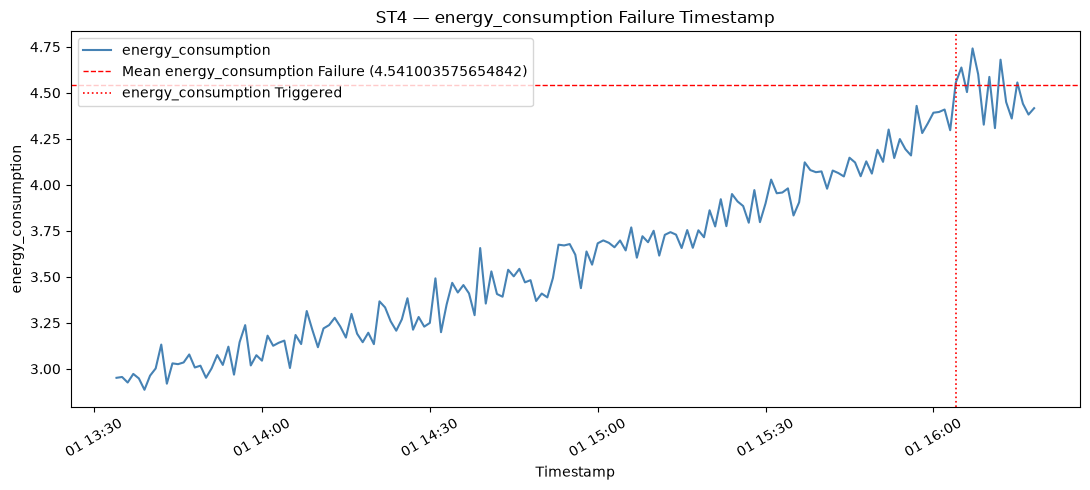

Target = 1: 5053 / 43185 (11.7%)
------ Evaluation: Random Forest --------
Threshold: 0.608
Accuracy: 0.9454
Precision: 0.7118
Recall: 0.8516
F1 Score: 0.7755
------------------------------
Accuracy in TRAIN: 0.9553
Accuracy in TEST:  0.9454
Gap: 0.0100
------------------------------
------ Evaluation: XGBoost --------
Threshold: 0.666
Accuracy: 0.9507
Precision: 0.7420
Recall: 0.8506
F1 Score: 0.7926
------------------------------
Accuracy in TRAIN: 0.9641
Accuracy in TEST:  0.9507
Gap: 0.0135
------------------------------


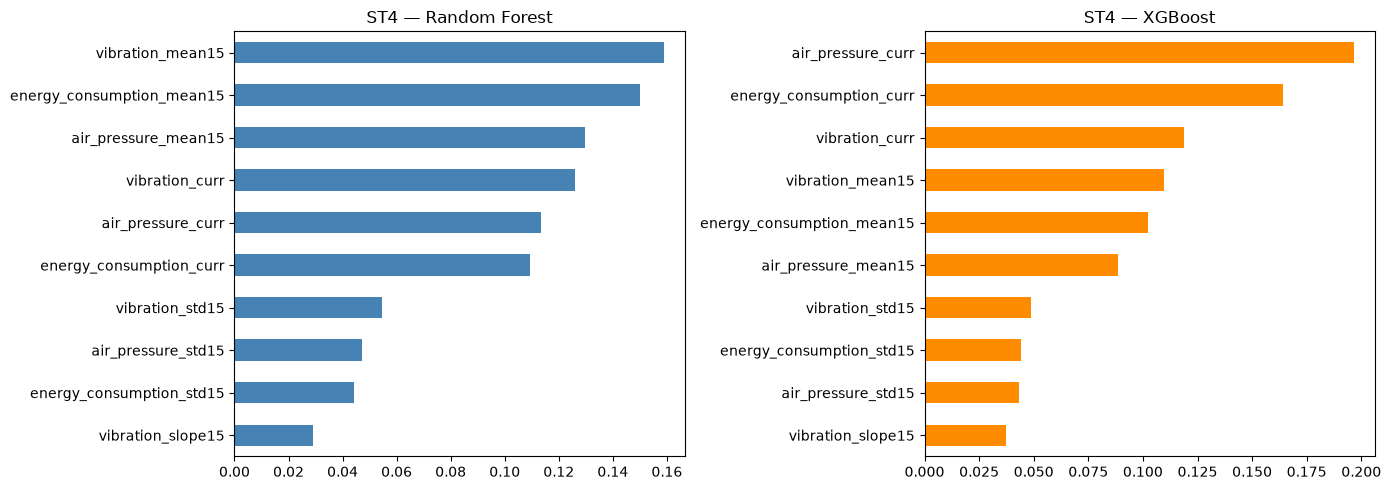

In [36]:
df_ST4 = Prepare_Station_Data(df_factory_minutely[df_factory_minutely['station_id'] == 'ST4'])

split_date = df_ST4['timestamp'].quantile(0.8)
split_train = df_ST4[df_ST4['timestamp'] < split_date]

sensors_ST4 = analyze_station_sensors(split_train, 'ST4')

df_ST4, feature_cols_ST4 = build_features_and_target(df_ST4, list(sensors_ST4.keys()))
result['ST4'] = {**train_evaluate_station_models(df_ST4, feature_cols_ST4, 'ST4'), 'sensors': sensors_ST4}
plot_feature_importances(result['ST4']['importances_rf'], result['ST4']['importances_xgb'], station_name='ST4')

In [37]:
result['ST4']['comparison']  

,Model,Accuracy,Precision,Recall,F1 Score,Train-Test Gap,Threshold
0,Random Forest,0.945351,0.711790,0.851620,0.775452,0.009957,0.607840
1,XGBoost,0.950677,0.742024,0.850575,0.792600,0.013460,0.665632


5. #### ST5 (Welding)

In [38]:
print(f"Station Type: {df_factory_minutely[df_factory_minutely['station_id'] == 'ST5']['station_type'].unique()[0]}")

Station Type: Welding


Sensors in ST5: ['vibration', 'air_pressure', 'temperature', 'energy_consumption', 'humidity'].
Mean vibration: 58.69414719567311
Min vibration: 57.57022791850296
Max vibration: 59.53813152206114
----------------------------------------
Mean air_pressure: 3.1890028764033382
Min air_pressure: 3.053114442639817
Max air_pressure: 3.363112661262797
----------------------------------------
Mean temperature: 89.65160979211781
Min temperature: 88.80074528047253
Max temperature: 90.91239328166164
----------------------------------------
Mean energy_consumption: 4.525354090870151
Min energy_consumption: 4.347286026010079
Max energy_consumption: 4.696236393424342
----------------------------------------
Mean humidity: 75.29495431530128
Min humidity: 73.67188625575173
Max humidity: 76.69369522922791
----------------------------------------


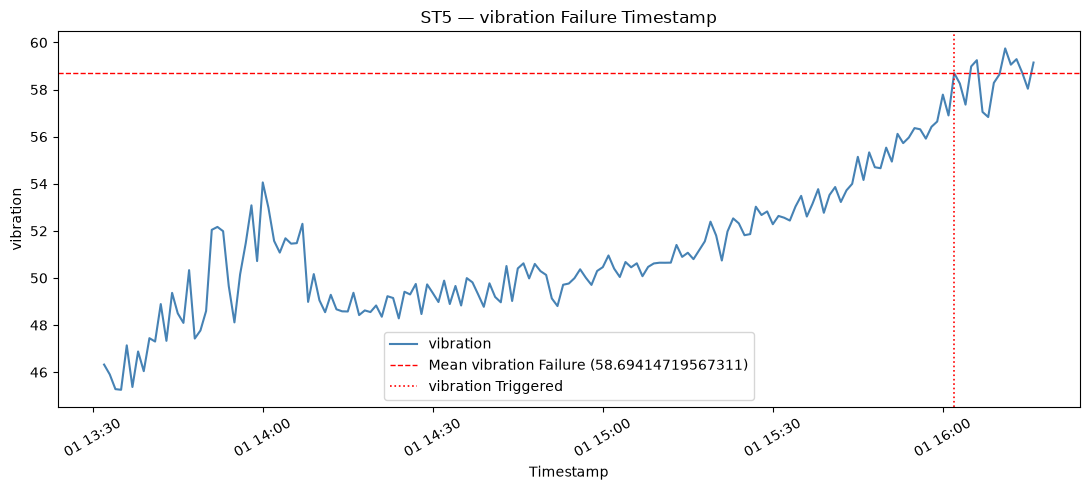

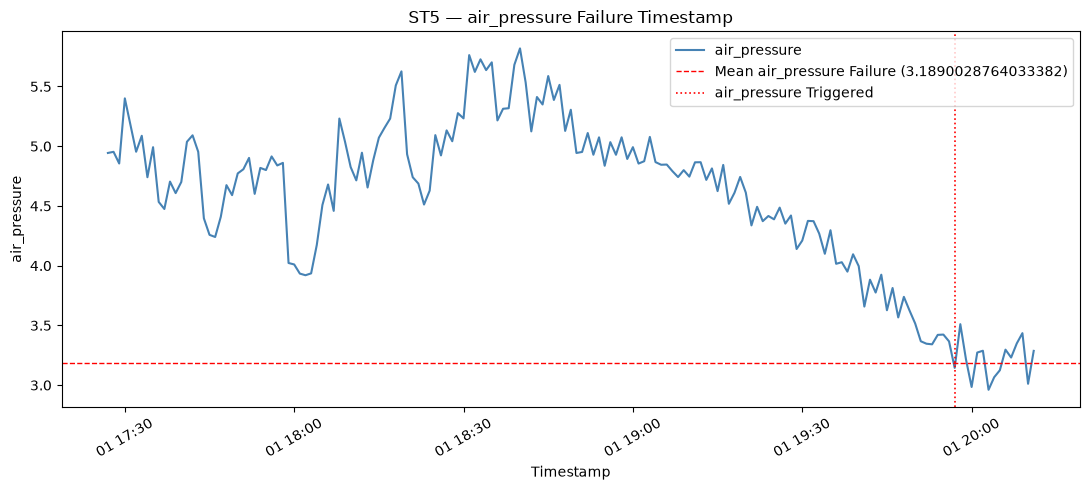

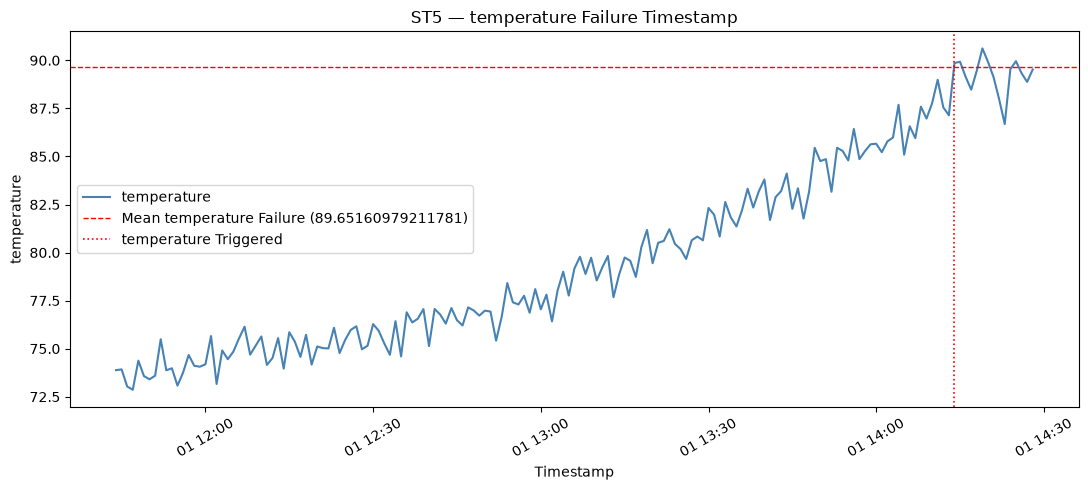

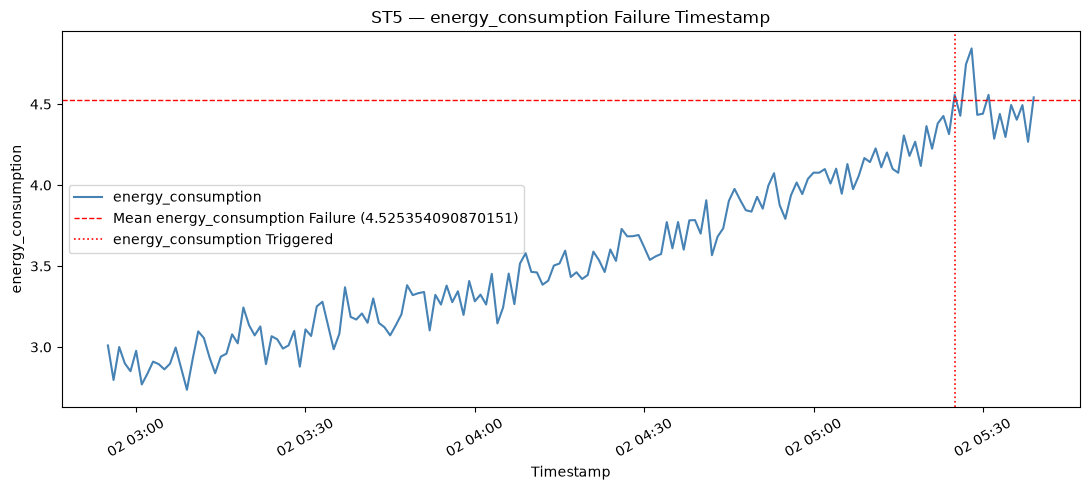

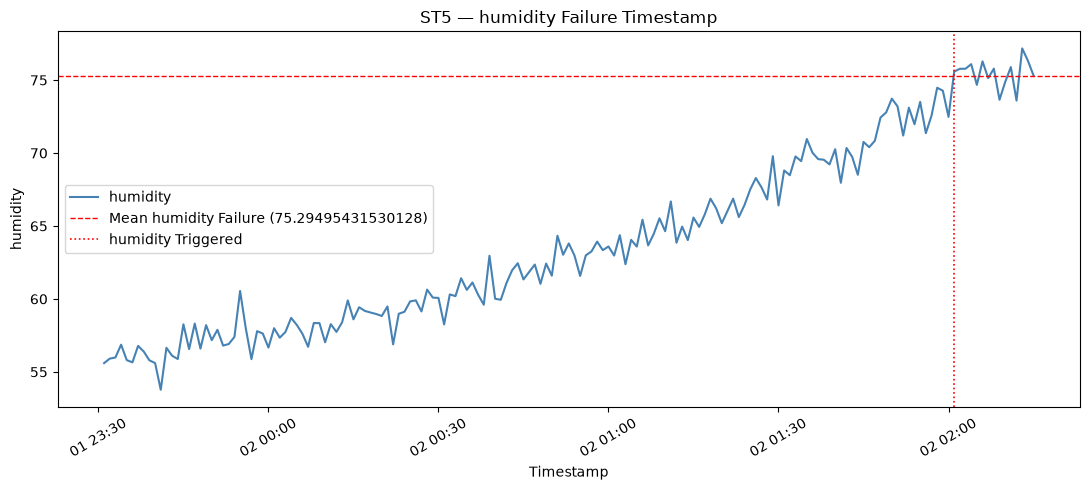

Target = 1: 7692 / 43185 (17.8%)
------ Evaluation: Random Forest --------
Threshold: 0.501
Accuracy: 0.9217
Precision: 0.7517
Recall: 0.8503
F1 Score: 0.7980
------------------------------
Accuracy in TRAIN: 0.9322
Accuracy in TEST:  0.9217
Gap: 0.0105
------------------------------
------ Evaluation: XGBoost --------
Threshold: 0.535
Accuracy: 0.9293
Precision: 0.7802
Recall: 0.8503
F1 Score: 0.8138
------------------------------
Accuracy in TRAIN: 0.9363
Accuracy in TEST:  0.9293
Gap: 0.0071
------------------------------


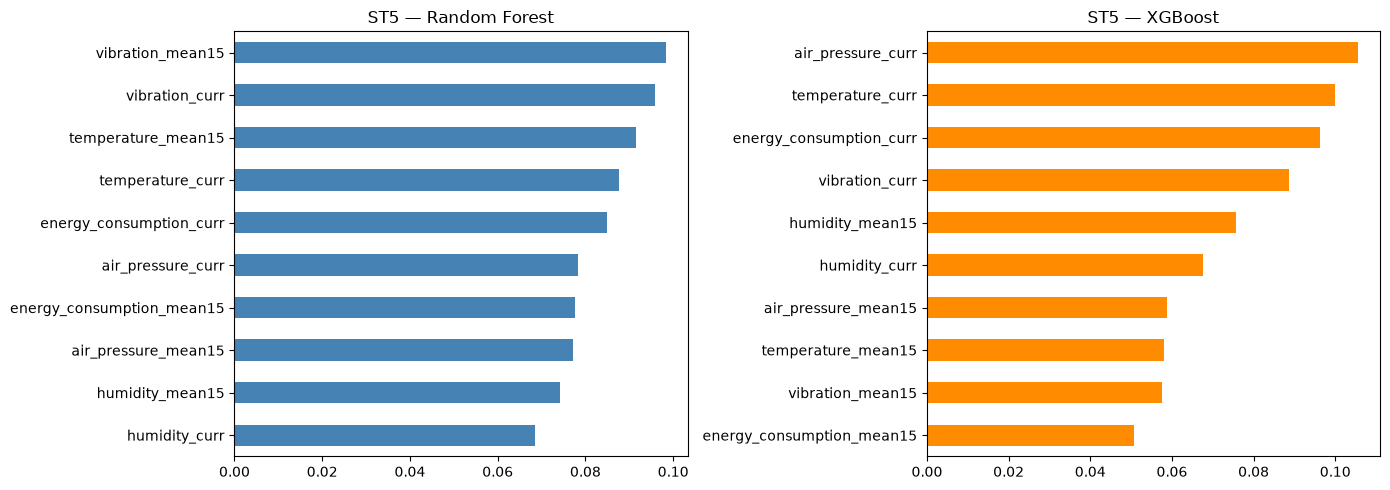

In [39]:
df_ST5 = Prepare_Station_Data(df_factory_minutely[df_factory_minutely['station_id'] == 'ST5'])

split_date = df_ST5['timestamp'].quantile(0.8)
split_train = df_ST5[df_ST5['timestamp'] < split_date]

sensors_ST5 = analyze_station_sensors(split_train, 'ST5')

df_ST5, feature_cols_ST5 = build_features_and_target(df_ST5, list(sensors_ST5.keys()))
result['ST5'] = {**train_evaluate_station_models(df_ST5, feature_cols_ST5, 'ST5'), 'sensors': sensors_ST5}
plot_feature_importances(result['ST5']['importances_rf'], result['ST5']['importances_xgb'], station_name='ST5')

In [40]:
result['ST5']['comparison']  

,Model,Accuracy,Precision,Recall,F1 Score,Train-Test Gap,Threshold
0,Random Forest,0.921732,0.751689,0.850318,0.797968,0.010507,0.500850
1,XGBoost,0.929258,0.780245,0.850318,0.813776,0.007063,0.535409


6. #### ST6 (Cooling_System)

In [41]:
print(f"Station Type: {df_factory_minutely[df_factory_minutely['station_id'] == 'ST6']['station_type'].unique()[0]}")

Station Type: Cooling_System


Sensors in ST6: ['air_pressure', 'temperature', 'energy_consumption', 'humidity'].
Mean air_pressure: 3.16821409494789
Min air_pressure: 2.962991296024302
Max air_pressure: 3.375920211106944
----------------------------------------
Mean temperature: 89.55780472485282
Min temperature: 88.16567490847136
Max temperature: 90.9246008296824
----------------------------------------
Mean energy_consumption: 4.536984793021032
Min energy_consumption: 4.344732253105833
Max energy_consumption: 4.681237673704121
----------------------------------------
Mean humidity: 75.38479951804733
Min humidity: 74.02965473433046
Max humidity: 76.41323730633304
----------------------------------------


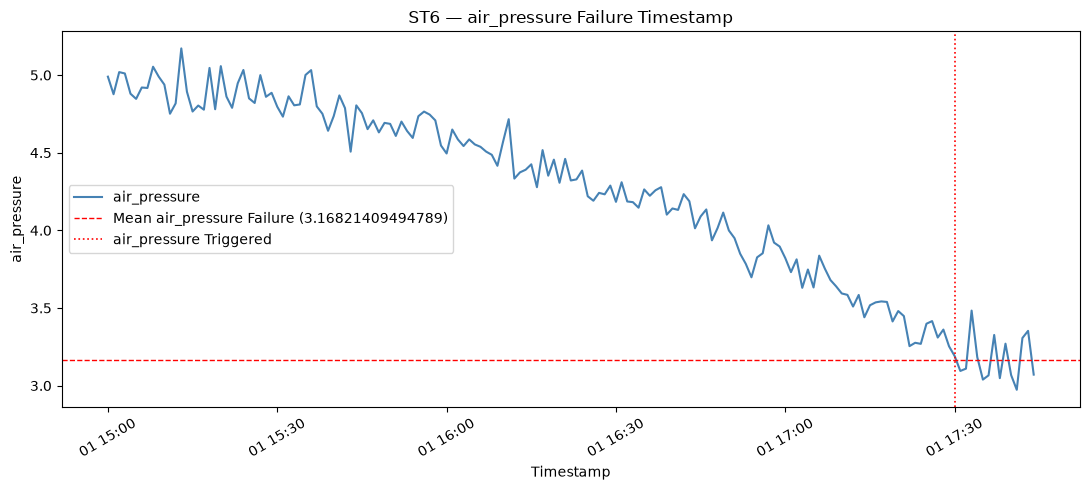

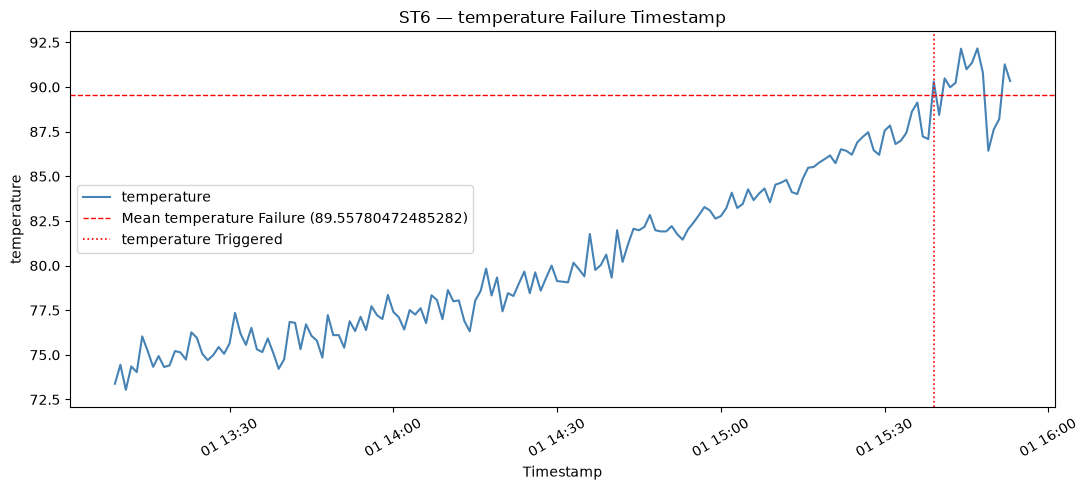

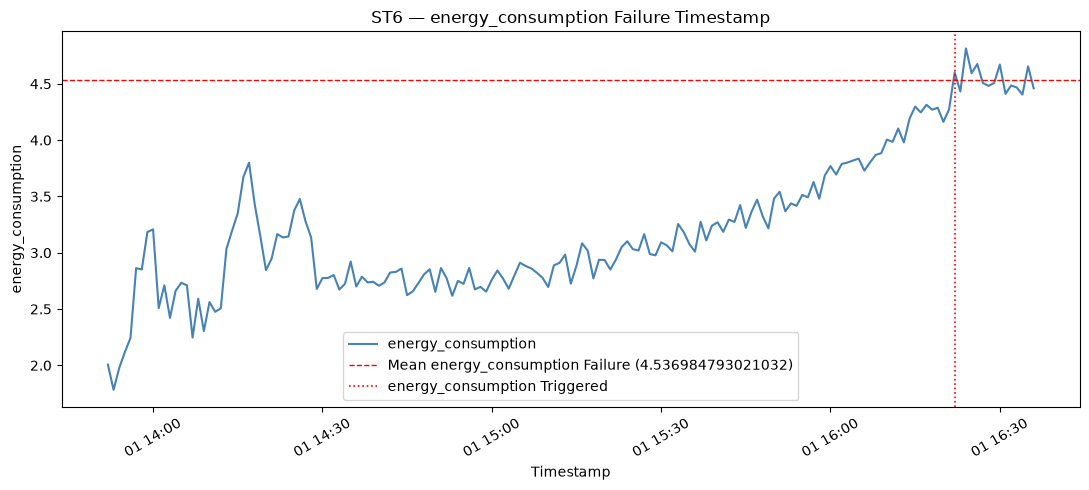

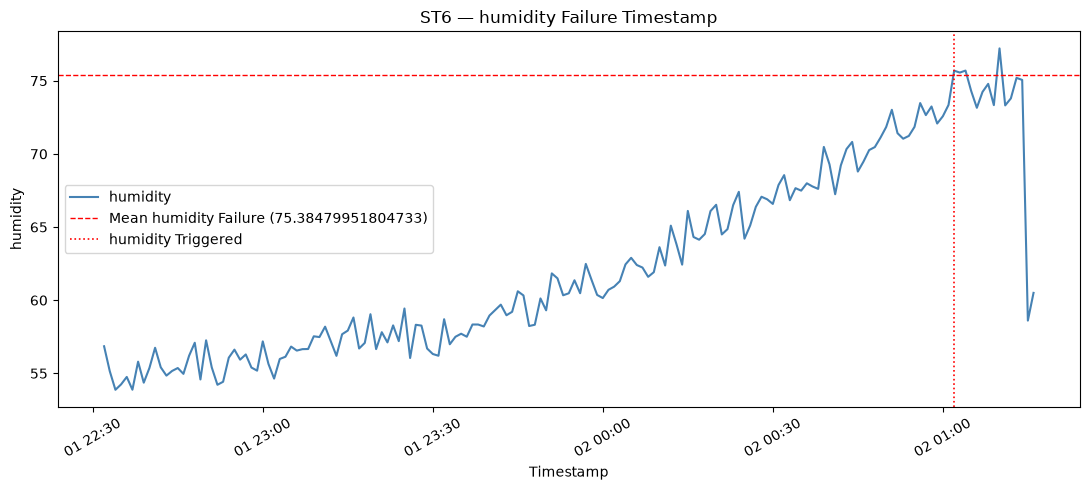

Target = 1: 6101 / 43185 (14.1%)
------ Evaluation: Random Forest --------
Threshold: 0.479
Accuracy: 0.9272
Precision: 0.6892
Recall: 0.8529
F1 Score: 0.7624
------------------------------
Accuracy in TRAIN: 0.9395
Accuracy in TEST:  0.9272
Gap: 0.0123
------------------------------
------ Evaluation: XGBoost --------
Threshold: 0.524
Accuracy: 0.9312
Precision: 0.7067
Recall: 0.8512
F1 Score: 0.7722
------------------------------
Accuracy in TRAIN: 0.9470
Accuracy in TEST:  0.9312
Gap: 0.0158
------------------------------


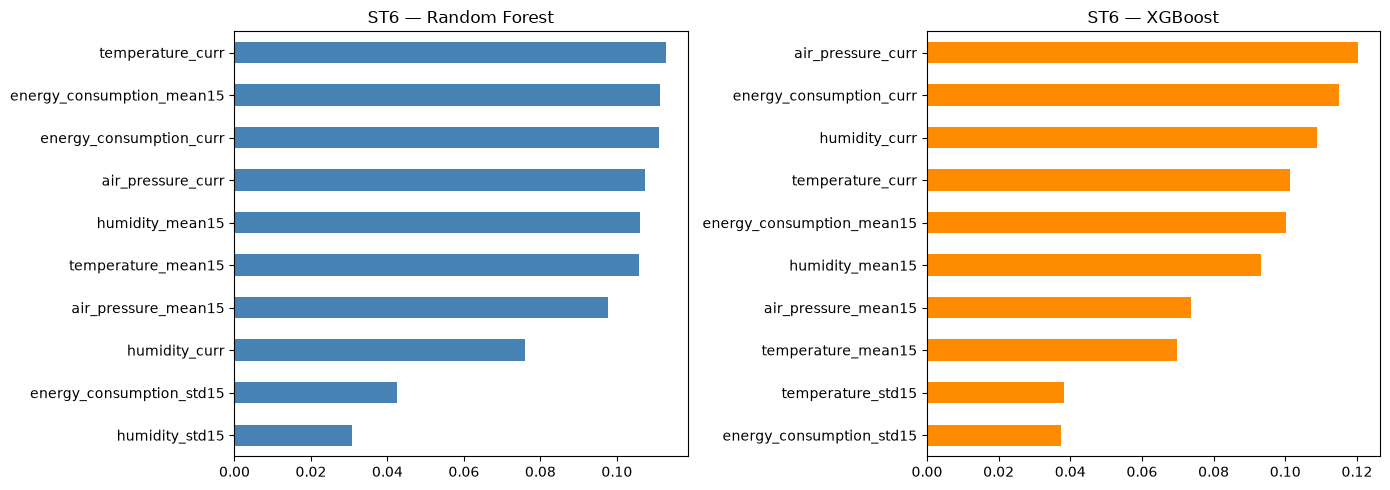

In [42]:
df_ST6 = Prepare_Station_Data(df_factory_minutely[df_factory_minutely['station_id'] == 'ST6'])

split_date = df_ST6['timestamp'].quantile(0.8)
split_train = df_ST6[df_ST6['timestamp'] < split_date]

sensors_ST6 = analyze_station_sensors(split_train, 'ST6')
df_ST6, feature_cols_ST6 = build_features_and_target(df_ST6, list(sensors_ST6.keys()))
result['ST6'] = {**train_evaluate_station_models(df_ST6, feature_cols_ST6, 'ST6'), 'sensors': sensors_ST6}
plot_feature_importances(result['ST6']['importances_rf'], result['ST6']['importances_xgb'], station_name='ST6')

In [43]:
result['ST6']['comparison']  

,Model,Accuracy,Precision,Recall,F1 Score,Train-Test Gap,Threshold
0,Random Forest,0.927174,0.689208,0.852916,0.762372,0.012331,0.479055
1,XGBoost,0.931226,0.706667,0.851226,0.772239,0.015775,0.524083


7. #### ST7 (Inspection)

In [44]:
print(f"Station Type: {df_factory_minutely[df_factory_minutely['station_id'] == 'ST7']['station_type'].unique()[0]}")

Station Type: Inspection


Sensors in ST7: ['energy_consumption'].
Mean energy_consumption: 4.53118124782015
Min energy_consumption: 4.403141513247695
Max energy_consumption: 4.629961277467894
----------------------------------------


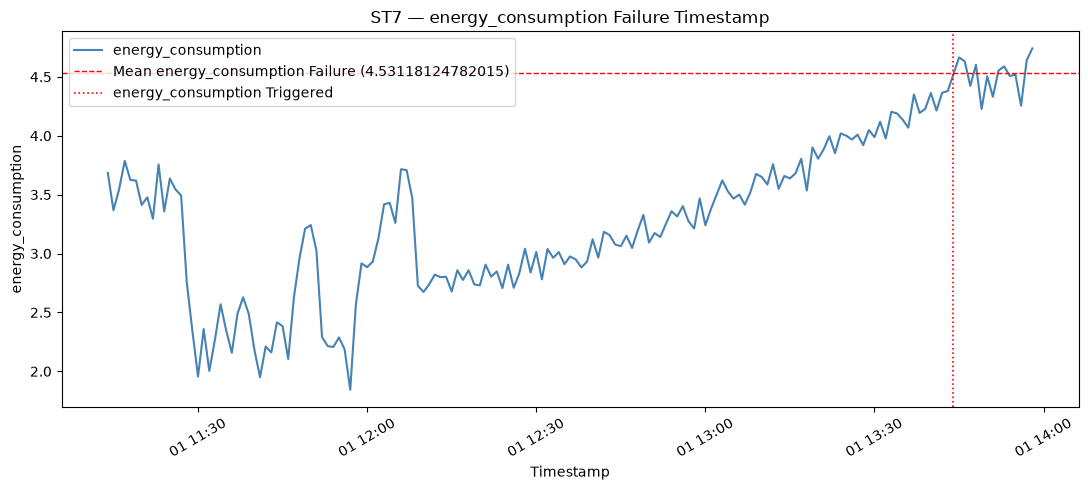

Target = 1: 2370 / 43185 (5.5%)
------ Evaluation: Random Forest --------
Threshold: 0.621
Accuracy: 0.9761
Precision: 0.7336
Recall: 0.8000
F1 Score: 0.7654
------------------------------
Accuracy in TRAIN: 0.9687
Accuracy in TEST:  0.9761
Gap: -0.0075
------------------------------
------ Evaluation: XGBoost --------
Threshold: 0.743
Accuracy: 0.9770
Precision: 0.7450
Recall: 0.8000
F1 Score: 0.7715
------------------------------
Accuracy in TRAIN: 0.9680
Accuracy in TEST:  0.9770
Gap: -0.0090
------------------------------


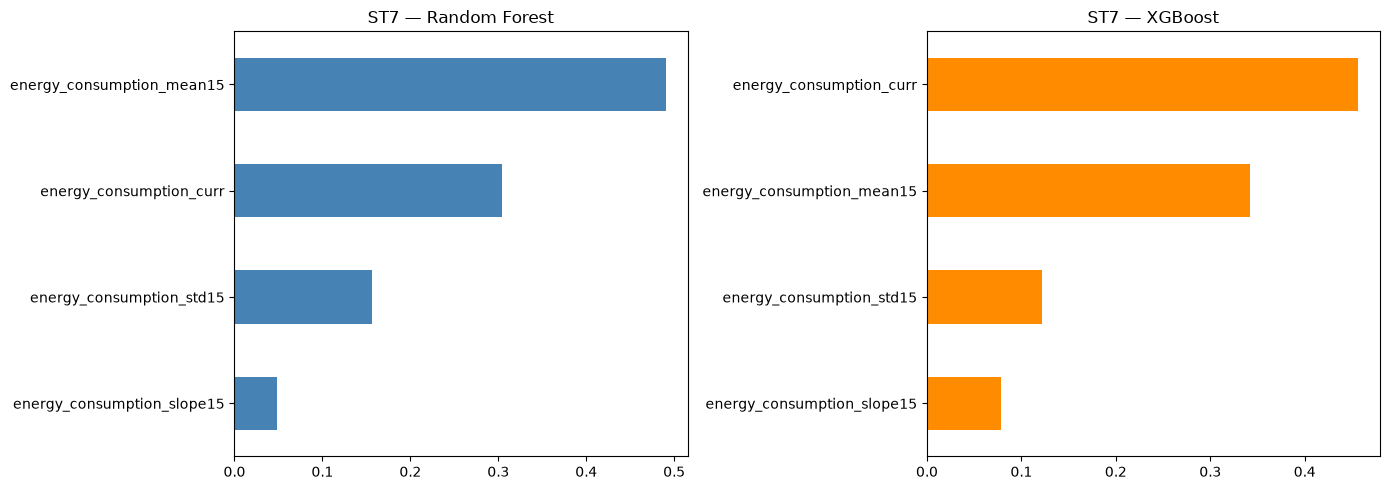

In [45]:
df_ST7 = Prepare_Station_Data(df_factory_minutely[df_factory_minutely['station_id'] == 'ST7'])

split_date = df_ST7['timestamp'].quantile(0.8)
split_train = df_ST7[df_ST7['timestamp'] < split_date]

sensors_ST7 = analyze_station_sensors(split_train, 'ST7')
df_ST7, feature_cols_ST7 = build_features_and_target(df_ST7, list(sensors_ST7.keys()))
result['ST7'] = {**train_evaluate_station_models(df_ST7, feature_cols_ST7, 'ST7'), 'sensors': sensors_ST7}
plot_feature_importances(result['ST7']['importances_rf'], result['ST7']['importances_xgb'], station_name='ST7')

In [46]:
result['ST7']['comparison']  

,Model,Accuracy,Precision,Recall,F1 Score,Train-Test Gap,Threshold
0,Random Forest,0.976149,0.733624,0.8,0.765376,-0.007497,0.621258
1,XGBoost,0.976960,0.745011,0.8,0.771527,-0.008973,0.742636


8. #### ST8 (Packaging)

In [47]:
print(f"Station Type: {df_factory_minutely[df_factory_minutely['station_id'] == 'ST8']['station_type'].unique()[0]}")

Station Type: Packaging


Sensors in ST8: ['vibration', 'air_pressure', 'energy_consumption', 'humidity'].
Mean vibration: 58.75989832412962
Min vibration: 57.66381785017975
Max vibration: 59.77081317404197
----------------------------------------
Mean air_pressure: 3.1643424038957773
Min air_pressure: 3.029702956167596
Max air_pressure: 3.271344201065151
----------------------------------------
Mean energy_consumption: 4.5459268061186995
Min energy_consumption: 4.427681640369331
Max energy_consumption: 4.6411377229414414
----------------------------------------


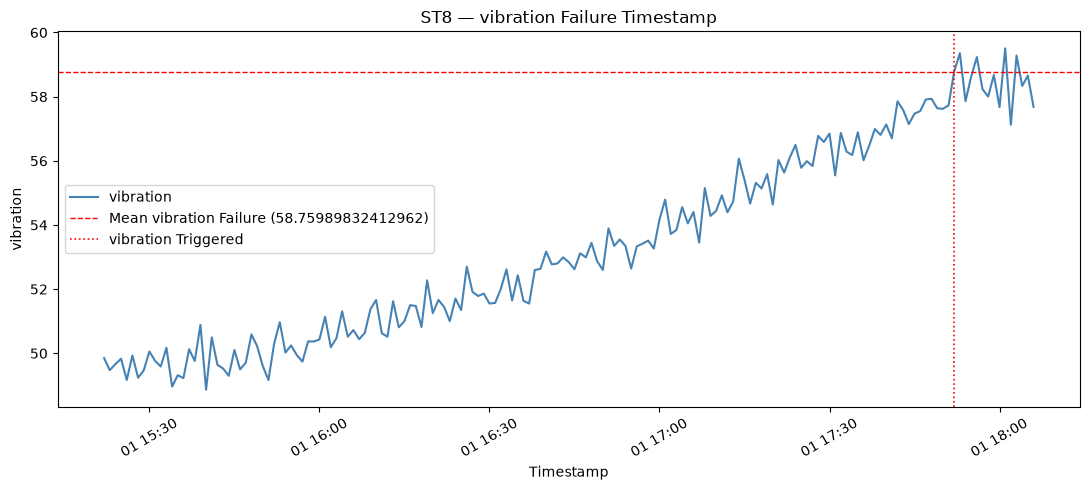

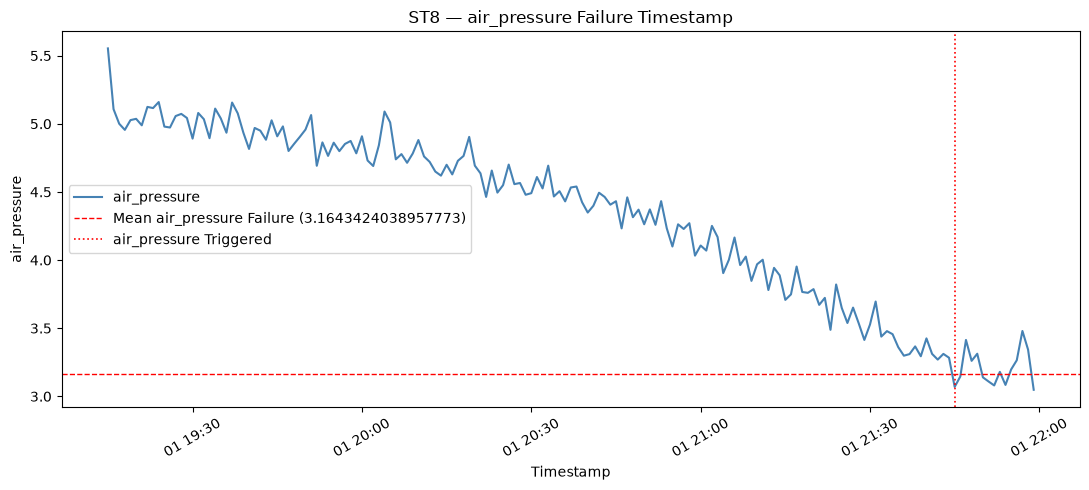

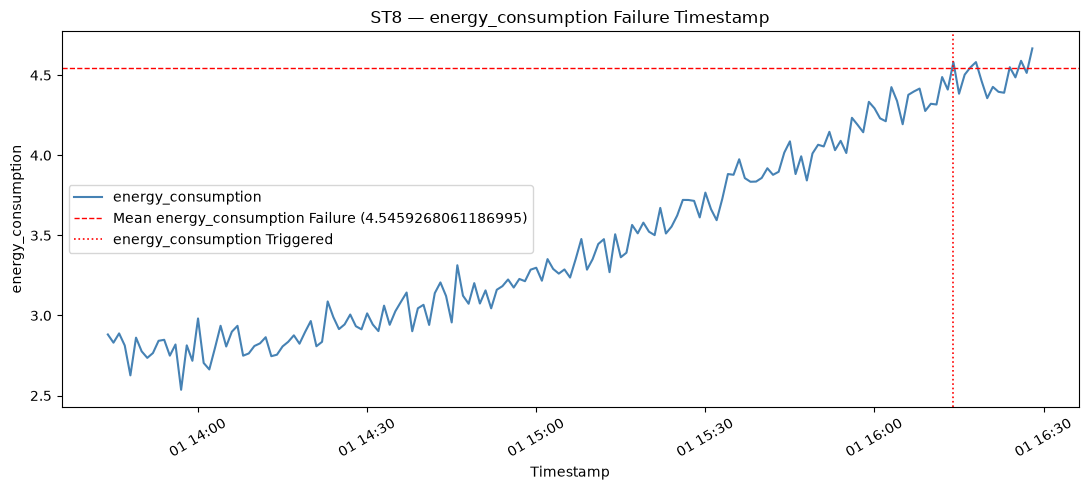

Target = 1: 5213 / 43185 (12.1%)
------ Evaluation: Random Forest --------
Threshold: 0.684
Accuracy: 0.9436
Precision: 0.6966
Recall: 0.9000
F1 Score: 0.7854
------------------------------
Accuracy in TRAIN: 0.9589
Accuracy in TEST:  0.9436
Gap: 0.0153
------------------------------
------ Evaluation: XGBoost --------
Threshold: 0.758
Accuracy: 0.9555
Precision: 0.7577
Recall: 0.9000
F1 Score: 0.8227
------------------------------
Accuracy in TRAIN: 0.9639
Accuracy in TEST:  0.9555
Gap: 0.0084
------------------------------


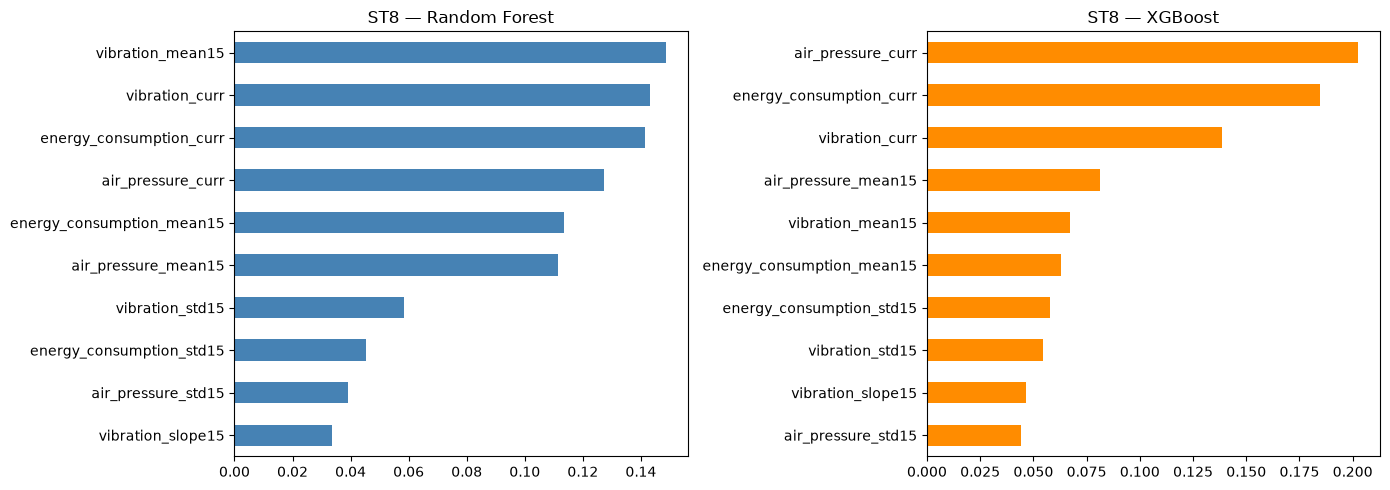

In [48]:
df_ST8 = Prepare_Station_Data(df_factory_minutely[df_factory_minutely['station_id'] == 'ST8'])

split_date = df_ST8['timestamp'].quantile(0.8)
split_train = df_ST8[df_ST8['timestamp'] < split_date]

sensors_ST8 = analyze_station_sensors(split_train, 'ST8')
df_ST8, feature_cols_ST8 = build_features_and_target(df_ST8, list(sensors_ST8.keys()))
result['ST8'] = {**train_evaluate_station_models(df_ST8, feature_cols_ST8, 'ST8'), 'sensors': sensors_ST8}
plot_feature_importances(result['ST8']['importances_rf'], result['ST8']['importances_xgb'], station_name='ST8')

In [49]:
result['ST8']['comparison']  

,Model,Accuracy,Precision,Recall,F1 Score,Train-Test Gap,Threshold
0,Random Forest,0.943615,0.696638,0.9,0.785368,0.015254,0.683700
1,XGBoost,0.955540,0.757653,0.9,0.822715,0.008394,0.757941


In [50]:

rows = []
for station in result:
    rf = result[station]['rf_eval']
    xgb = result[station]['xgb_eval']

    rows.append({
        'Station': station,
        'Model': 'Random Forest',
        'Accuracy': rf['acc'], 'Precision': rf['prec'], 'Recall': rf['rec'],
        'F1 Score': rf['f1'], 'Train-Test Gap': rf['gap'],
        'Threshold': result[station]['threshold_rf'],   # <- nuevo
    })
    rows.append({
        'Station': station,
        'Model': 'XGBoost',
        'Accuracy': xgb['acc'], 'Precision': xgb['prec'], 'Recall': xgb['rec'],
        'F1 Score': xgb['f1'], 'Train-Test Gap': xgb['gap'],
        'Threshold': result[station]['threshold_xgb'],   # <- nuevo
    })

comparison_all = pd.DataFrame(rows)


rows = []
for station in result:
    rf = result[station]['rf_eval']
    xgb = result[station]['xgb_eval']

    rows.append({
        'Station': station,
        'Model': 'Random Forest',
        'Accuracy': rf['acc'], 'Precision': rf['prec'], 'Recall': rf['rec'],
        'F1 Score': rf['f1'], 'Train-Test Gap': rf['gap'],
        'Threshold': result[station]['threshold_rf'],
    })
    rows.append({
        'Station': station,
        'Model': 'XGBoost',
        'Accuracy': xgb['acc'], 'Precision': xgb['prec'], 'Recall': xgb['rec'],
        'F1 Score': xgb['f1'], 'Train-Test Gap': xgb['gap'],
        'Threshold': result[station]['threshold_xgb'],
    })

comparison_all = pd.DataFrame(rows)

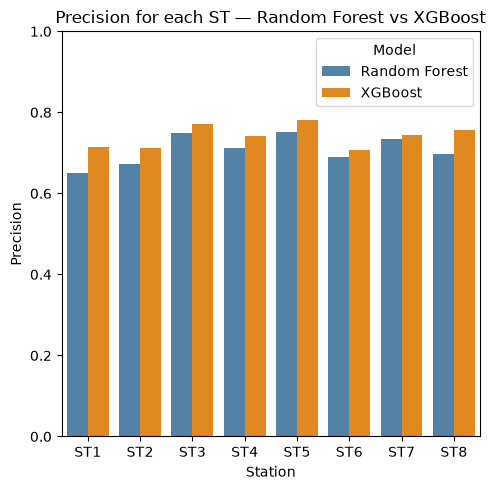

In [51]:
plt.figure(figsize=(5, 5))
sns.barplot(data=comparison_all, x='Station', y='Precision', hue='Model', palette=['steelblue', 'darkorange'])
plt.title('Precision for each ST — Random Forest vs XGBoost')
plt.ylim(0,1)
plt.tight_layout()
plt.show()

In [52]:
comparison_all

,Station,Model,Accuracy,Precision,Recall,F1 Score,Train-Test Gap,Threshold
0,ST1,Random Forest,0.903670,0.651163,0.900699,0.755869,0.025617,0.431301
1,ST1,XGBoost,0.923932,0.714603,0.900000,0.796657,0.021448,0.553186
2,ST2,Random Forest,0.901586,0.672613,0.850133,0.751025,0.033721,0.542344
3,ST2,XGBoost,0.913627,0.711197,0.850796,0.774758,0.029177,0.580225
4,ST3,Random Forest,0.937478,0.750000,0.900000,0.818182,0.012852,0.690312
5,ST3,XGBoost,0.942573,0.770939,0.900000,0.830485,0.012273,0.727826
6,ST4,Random Forest,0.945351,0.711790,0.851620,0.775452,0.009957,0.607840
7,ST4,XGBoost,0.950677,0.742024,0.850575,0.792600,0.013460,0.665632
8,ST5,Random Forest,0.921732,0.751689,0.850318,0.797968,0.010507,0.500850
9,ST5,XGBoost,0.929258,0.780245,0.850318,0.813776,0.007063,0.535409


**Conclusions:**

_(Detect Fail [Target = 1])_
- **Accuracy    :** Not the best metric here, Accuracy is high because of the imbalanced class [16% = 1 / 84% = 0]. 
                    A model that always predicts "no failure" would still score ~84% accuracy while being useless.
- **Precision   :** Indicates of all predicted failures, how many were real failures. Low precision = too many false alarms.
- **Recall      :** Indicates of all the real failures, how many the model actually detect. Low recall = failures undetected.
- **F1 Score    :** Indicates if there is good balance between false alarms and missed failures. F1 Score is harmonic mean of Precision and Recall. 




**Decision:** 

- XGBoost is the model selected regarding better results.

- In Industrial Business is more costly missed failures than false alarms. 
So, Recall is the primary metric.

**Scope decision — Blocked & Starved excluded from the predictive model:**

Blocked and Starved are **process/flow-related stoppages**, not equipment failures:
- **Blocked**: caused by downstream congestion (the next station isn't consuming fast enough), not a machine fault.
- **Starved**: caused by upstream supply gaps — either flow-based (previous station not producing) or, only at Robotics stations (ST1, ST3), by delayed operator resupply.

Neither has a physical sensor precursor. When tested with neighbor-based features (recent downtime % of adjacent stations), the best achievable recall was ~0.50, far below the ~0.85–0.95 achieved for Mechanical/Electrical using real sensor signals.

Since this project's goal is **predictive maintenance of equipment failures**, the model scope is intentionally limited to Mechanical and Electrical — the failure types with genuine physical precursors. Blocked/Starved would require a separate line-balancing/flow-optimization analysis, outside this project's scope.

#### Export Best Trained Models for ST

In [53]:
best_model_choice = {}
for station in result:
    rf_prec = result[station]['rf_eval']['prec']
    xgb_prec = result[station]['xgb_eval']['prec']
    best_model_choice[station] = 'xgb' if xgb_prec >= rf_prec else 'rf'

print(best_model_choice)

{'ST1': 'xgb', 'ST2': 'xgb', 'ST3': 'xgb', 'ST4': 'xgb', 'ST5': 'xgb', 'ST6': 'xgb', 'ST7': 'xgb', 'ST8': 'xgb'}


- Checking the results the trained models selected will be XGBoost for all the ST, as we "forced" minimum recall, the best model will be the one that has better precision.


In [54]:
# ---- Exportar SOLO el modelo ganador + columnas de test_df realmente usadas ----
import pickle

CAUSE_COLS = ['cause_Mechanical', 'cause_Electrical', 'cause_Blocked',
              'cause_Starved', 'cause_Changeover', 'cause_Quality']

slim_result = {}
for station in result:
    r = result[station]
    model_key = best_model_choice[station]
    feature_cols = r['feature_cols']

    needed_cols = ['timestamp', 'is_running', 'target', 'trigger_sensor'] + CAUSE_COLS + feature_cols
    needed_cols = [c for c in dict.fromkeys(needed_cols) if c in r['test_df'].columns]  # sin duplicados, solo si existen

    slim_result[station] = {
        'model': r[model_key],
        'model_key': model_key,
        'feature_cols': feature_cols,
        'sensors': r['sensors'],
        'threshold': r[f'threshold_{model_key}'],
        'eval': r[f'{model_key}_eval'],
        'last_row': r['df'][feature_cols].iloc[[-1]].copy(),
        'test_df': r['test_df'][needed_cols].copy(),   # <- solo las columnas que la app usa de verdad
    }

with open('trained_models/trained_models.pkl', 'wb') as f:
    pickle.dump(slim_result, f)

print("Done!")

Done!
